Link looker studio :
https://datastudio.google.com/reporting/44c5e43f-e293-45c1-b856-3f7032f33406

# I. Introduction

This program is built to explore and analyze data end-to-end — starting with Exploratory Data Analysis (EDA), applying the SMART framework, drawing insights through foundational statistical analysis, and bringing the data to life with visualizations powered by Python libraries such as Matplotlib, Seaborn, and Plotly.

# II. Exploratory Data Analysis (EDA)

In [4]:
# Import library pandas for EDA
import pandas as pd 

In [5]:
# Read csv file as pandas dataframe
df = pd.read_csv('Telco-Customer-Churn.csv', delimiter=',')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
# Show dataframe description to see numerical columns statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Show dataframe summary to assess dataframe rows and columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# III. Data Cleaning

## Check Missing Values

In [8]:
df.isnull().sum() # Result: No missing values 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Check Data Duplicates

In [9]:
df.duplicated().sum() # Result: No data duplicates

np.int64(0)

## Check Data Types

In [10]:
df.dtypes 

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Result:

1. The TotalCharges column has been converted from string to float data type.
2. A new column Is_Security_Add_Ons has been added with string data type and Yes/No values.
3. The Churn column will be converted to 0 and 1 during the ETL process for data modeling purposes, but will remain as is during EDA.

## Convert Data Type

In [11]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)

df['TotalCharges'] = df['TotalCharges'].astype(float)

## Add New Column

In [12]:
security_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

df['Is_Security_Add_Ons'] = df[security_cols].eq('Yes').any(axis=1).map({True: 'Yes', False: 'No'})

In [13]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Is_Security_Add_Ons
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Yes
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,Yes
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,Yes
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Yes
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,No


# IV. Business Problem Identification

Data Reference Source : https://www.kaggle.com/datasets/abbas829/telco-customer-churn-dataset/data

In [14]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
'''
We use the pandas package for data processing, 
scipy for processing the two-sample independent hypothesis, 
numpy for calculating averages, and etc. 
Matplotlib.pyplot and seaborn for visualization.
'''

df.info() # show data structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   object 
 1   gender               7043 non-null   object 
 2   SeniorCitizen        7043 non-null   int64  
 3   Partner              7043 non-null   object 
 4   Dependents           7043 non-null   object 
 5   tenure               7043 non-null   int64  
 6   PhoneService         7043 non-null   object 
 7   MultipleLines        7043 non-null   object 
 8   InternetService      7043 non-null   object 
 9   OnlineSecurity       7043 non-null   object 
 10  OnlineBackup         7043 non-null   object 
 11  DeviceProtection     7043 non-null   object 
 12  TechSupport          7043 non-null   object 
 13  StreamingTV          7043 non-null   object 
 14  StreamingMovies      7043 non-null   object 
 15  Contract             7043 non-null   o

**Background:**
Telco is a company that provides landline telephone and internet services across California, United States. Telco offers several products, including phone service, multiple lines, streaming TV, and streaming movies. In addition, internet services are available through DSL (modem) and fiber optic connections. The company also provides additional services in the form of security add-ons, such as Online Security, Online Backup, Device Protection, and Tech Support.

**Problem Topic:**
There is customer churn that causes a decrease in revenue, along with the lack of identification of potential market segments for promotional activities, resulting in difficulties in reducing the churn rate.

---

## **Problem Statement (SMART Method):**

**Objective:**
How can the churn rate be reduced by 1% within 2 months by providing promotional programs aimed at retaining existing subscribed customers of the product.

**Specific:**
Reduce the churn rate by providing promotional programs with a target reduction of 1%.

**Measurable:**
Achieve a 1% decrease in churn rate from the total customer base.

**Achievable:**
Reduce the churn rate through the implementation of promotional offers for customers.

**Relevant:**
Reducing churn is necessary to improve the company’s profitability by retaining customers who have subscribed to the company’s products.

**Time-bound:**
2 months.

---

**Problem Breakdown:**

1. What is the comparison of the percentage between churned and non-churned customers from the overall customer base in the most recent month?
2. What is the percentage of churn based on customer characteristics (gender, senior citizen status, partner status, dependents, contract type, and payment method)?
3. What is the churn rate based on product services (phone service, multiple lines, streaming TV, and streaming movies)?
4. What is the churn percentage across each security add-on service (Online Security, Online Backup, Device Protection, and Tech Support)?
5. What is the distribution of total charges among churned and non-churned customers? Additionally, how does the monthly charge relate to churn?
6. How is customer data distributed based on tenure? Is there a difference in churn rate compared to non-churn customers, and what the correlation between tenure and churn?
7. What is the top 10 that have high percentage in churn?


## 1. What is the comparison of the percentage between churned and non-churned customers from the overall customer base in the most recent month?

In [15]:
total_churn = (
    df.groupby("Churn", as_index=False)["customerID"].count())
print(total_churn) # Count the number of churn occurrences per ID and store it in the variable total_churn

churn_yes = df[df['Churn'] == 'Yes']
churn_no = df[df['Churn'] == 'No']
yes_pres = len(churn_yes) / len(df) * 100
no_pres = len(churn_no) / len(df) * 100
print(f'Number of customers who churned: {len(churn_yes)}')
print(f'Number of customers who did not churn: {len(churn_no)}')
print(f'Percentage of customers who churned: {yes_pres:.2f}%')
print(f'Percentage of customers who did not churn: {no_pres:.2f}%')



  Churn  customerID
0    No        5174
1   Yes        1869
Number of customers who churned: 1869
Number of customers who did not churn: 5174
Percentage of customers who churned: 26.54%
Percentage of customers who did not churn: 73.46%


C:\Users\User\AppData\Local\Temp\ipykernel_37948\2740364696.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1))


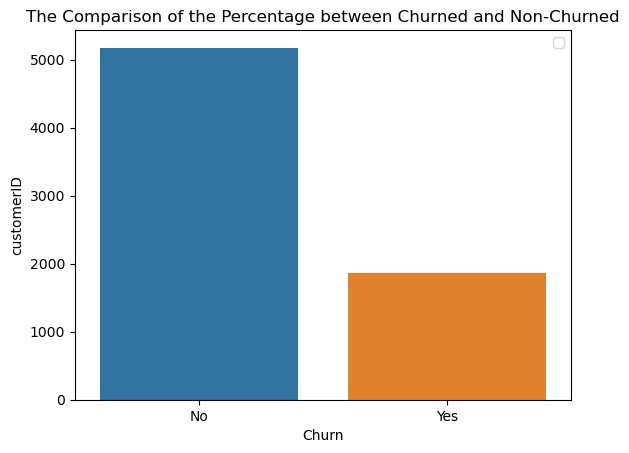

In [16]:
sns.barplot(
    data=total_churn, x="Churn", y="customerID", orient="v", hue="Churn"
)

plt.legend(bbox_to_anchor=(1, 1)) 
plt.title("The Comparison of the Percentage between Churned and Non-Churned")
plt.show()

The churn condition shows that 1,869 customers (26.54%) have churned, while 5,174 customers (73.46%) have continue using the service.


## 2. What is the percentage of churn based on customer characteristics (gender, senior citizen status, partner status, dependents, contract type, and payment method)?

### a. Gender

In [17]:
F_Gen = df[df['gender'] == 'Female']
M_Gen = df[df['gender'] == 'Male']
F_pres = len(F_Gen) / len(df) * 100
M_pres = len(M_Gen) / len(df) * 100
print(f'Number of female customers: {len(F_Gen)}')
print(f'Number of male customers: {len(M_Gen)}')
print(f'Percentage of female customers: {F_pres:.2f}%')
print(f'Percentage of male customers: {M_pres:.2f}%')

Number of female customers: 3488
Number of male customers: 3555
Percentage of female customers: 49.52%
Percentage of male customers: 50.48%


In [18]:
F_Churn_Yes = F_Gen[F_Gen['Churn'] == 'Yes']
M_Churn_Yes = M_Gen[M_Gen['Churn'] == 'Yes']
FCY_Pres = len(F_Churn_Yes) / len(F_Gen) * 100
MCY_Pres = len(M_Churn_Yes) / len(M_Gen) * 100
print(f'Number of male customers who churned = {len(M_Churn_Yes)}, Number of female customers who churned = {len(F_Churn_Yes)}')
print(f'Percentage of male customers who churned = {MCY_Pres:.2f}%, Percentage of female customers who churned = {FCY_Pres:.2f}%')


Number of male customers who churned = 930, Number of female customers who churned = 939
Percentage of male customers who churned = 26.16%, Percentage of female customers who churned = 26.92%


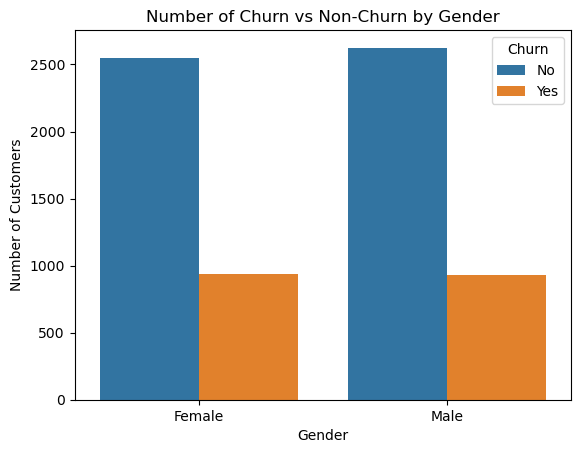

In [19]:
sns.countplot(
    data=df,
    x='gender',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

The difference is not significant, with only a gap of 9 customers, where females (26.92%) have a slightly higher churn compared to males (26.16%), or a 0.76% difference based on percentage.

### b. Senior citizen

In [20]:
SCz_1 = df[df['SeniorCitizen'] == 1]
SCz_0 = df[df['SeniorCitizen'] == 0]
S1_pres = len(SCz_1) / len(df) * 100
S0_pres = len(SCz_0) / len(df) * 100
print(f'Number of senior citizen customers = {len(SCz_1)}, Number of non-senior citizen customers = {len(SCz_0)}')
print(f'Percentage of senior citizen customers = {S1_pres:.2f}%, Percentage of non-senior citizen customers = {S0_pres:.2f}%')

Number of senior citizen customers = 1142, Number of non-senior citizen customers = 5901
Percentage of senior citizen customers = 16.21%, Percentage of non-senior citizen customers = 83.79%


In [21]:
SCz_1_Yes = SCz_1[SCz_1['Churn'] == 'Yes']
SCz_0_Yes = SCz_0[SCz_0['Churn'] == 'Yes']
S1Y_Pres = len(SCz_1_Yes) / len(SCz_1) * 100
S0Y_Pres = len(SCz_0_Yes) / len(SCz_0) * 100
print(f'Number of senior citizen customers who churned = {len(SCz_1_Yes)} from {len(SCz_1)}, Number of non-senior citizen customers who churned = {len(SCz_0_Yes)} from {len(SCz_0)}')
print(f'Percentage of senior citizen customers who churned = {S1Y_Pres:.2f}%, Percentage of non-senior citizen customers who churned = {S0Y_Pres:.2f}%')

Number of senior citizen customers who churned = 476 from 1142, Number of non-senior citizen customers who churned = 1393 from 5901
Percentage of senior citizen customers who churned = 41.68%, Percentage of non-senior citizen customers who churned = 23.61%


C:\Users\User\AppData\Local\Temp\ipykernel_37948\1390712679.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kind, y=customer, ax=ax1, palette="Blues_d")


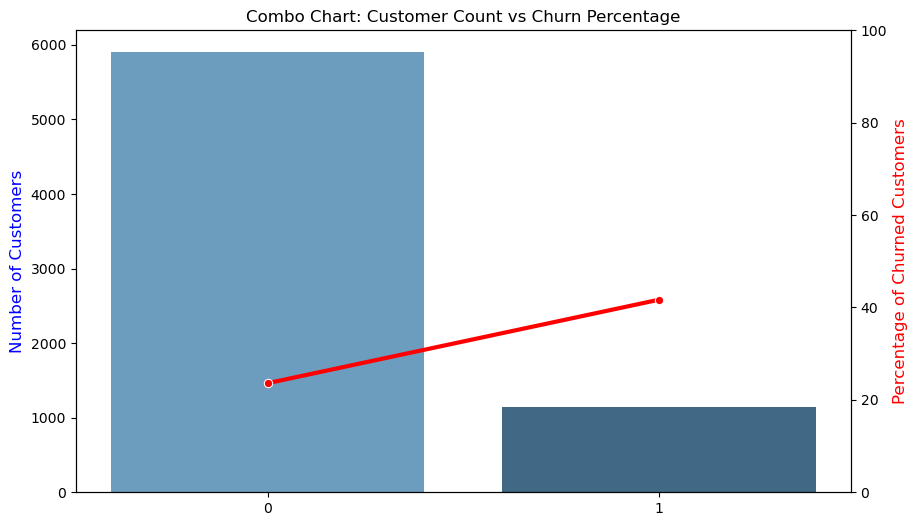

In [22]:

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup your data
data = df
kind = data['SeniorCitizen'].unique()
customer = data.groupby('SeniorCitizen')['customerID'].count()
churn = data.groupby('SeniorCitizen')['Churn'].apply(lambda x: (x == 'Yes').mean()) * 100

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(x=kind, y=customer, ax=ax1, palette="Blues_d")
ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(x=kind, y=churn, marker='o', color='red', linewidth=3, ax=ax2)
ax2.set_ylabel('Percentage of Churned Customers', color='red', fontsize=12)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Senior Citizen, 0 = Bukan Lansia, 1 = Lansia')
plt.show()

Number of senior citizen customers = 1142, 
Number of non-senior citizen customers = 5901

Percentage of senior citizen customers = 16.21%, 
Percentage of non-senior citizen customers = 83.79%

Number of senior citizen customers who churned = 476 from 1142, 
Number of non-senior citizen customers who churned = 1393 from 5901.

Percentage of senior citizen customers who churned = 41.68%, 
Percentage of non-senior citizen customers who churned = 23.61%

It shows a difference of around 18%, with senior citizens having a higher churn rate compared to non-senior citizens when measured relative to their respective group sizes.

### c. Partner

In [23]:
PY = df[df['Partner'] == 'Yes']
PN = df[df['Partner'] == 'No']
PY_pres = len(PY) / len(df) * 100
PN_pres = len(PN) / len(df) * 100
print(f'Number of customers who have a partner = {len(PY)}, Number of customers who do not have a partner = {len(PN)}')
print(f'Percentage of customers who have a partner = {PY_pres:.2f}%, Percentage of customers who do not have a partner = {PN_pres:.2f}%')

Number of customers who have a partner = 3402, Number of customers who do not have a partner = 3641
Percentage of customers who have a partner = 48.30%, Percentage of customers who do not have a partner = 51.70%


In [24]:
PY_Churn_Yes = PY[PY['Churn'] == 'Yes']
PN_Churn_Yes = PN[PN['Churn'] == 'Yes']
PYCY_Pres = len(PY_Churn_Yes) / len(PY) * 100
PNCY_Pres = len(PN_Churn_Yes) / len(PN) * 100
print(f'Number of customers with a partner who churned = {len(PY_Churn_Yes)} from {len(PY)}, Number of customers without a partner who churned = {len(PN_Churn_Yes)} from {len(PN)}')
print(f'Percentage of customers with a partner who churned = {PYCY_Pres:.2f}%, Percentage of customers without a partner who churned = {PNCY_Pres:.2f}%')

Number of customers with a partner who churned = 669 from 3402, Number of customers without a partner who churned = 1200 from 3641
Percentage of customers with a partner who churned = 19.66%, Percentage of customers without a partner who churned = 32.96%


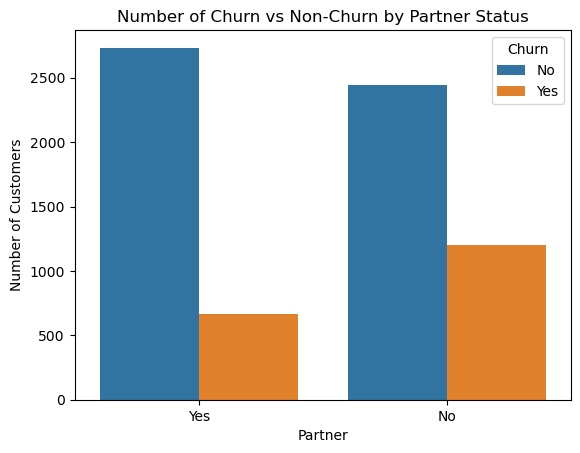

In [25]:
sns.countplot(
    data=df,
    x='Partner',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\2284361061.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


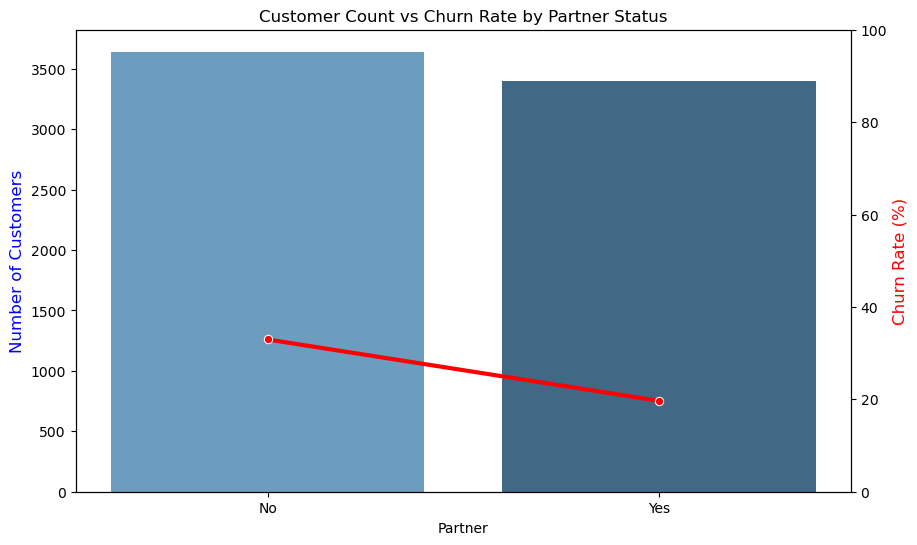

In [26]:
# 1. Setup data
data = df

aggregated_data = data.groupby('Partner').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['Partner'].unique()

# customer = data.groupby('Partner')['customerID'].count()

# churn = (
#     data.groupby('Partner')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['Partner'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette='Blues_d'
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create second Y-axis
ax2 = ax1.twinx()

# 4. Create second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['Partner'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel('Churn Rate (%)', color='red', fontsize=12)

# Biar persen 0–100
ax2.set_ylim(0, 100)

plt.title('Customer Count vs Churn Rate by Partner Status')
plt.xlabel('Partner Status')

plt.show()

It shows a difference of around 14%, with customers who do not have a partner exhibiting a higher churn rate compared to those who have a partner, when measured relative to their respective group sizes.

### d. Dependents

In [27]:
DY = df[df['Dependents'] == 'Yes']
DN = df[df['Dependents'] == 'No']
DY_pres = len(DY) / len(df) * 100
DN_pres = len(DN) / len(df) * 100
print(f'Number of customers with dependents = {len(DY)}, Number of customers without dependents = {len(DN)}')
print(f'Percentage of customers with dependents = {DY_pres:.2f}%, Percentage of customers without dependents = {DN_pres:.2f}%')

Number of customers with dependents = 2110, Number of customers without dependents = 4933
Percentage of customers with dependents = 29.96%, Percentage of customers without dependents = 70.04%


In [28]:
DY_Churn_Yes = DY[DY['Churn'] == 'Yes']
DN_Churn_Yes = DN[DN['Churn'] == 'Yes']
DYCY_Pres = len(DY_Churn_Yes) / len(DY) * 100
DNCY_Pres = len(DN_Churn_Yes) / len(DN) * 100
print(f'Number of customers with dependents who churned = {len(DY_Churn_Yes)} from {len(DY)}, Number of customers without dependents who churned = {len(DN_Churn_Yes)} from {len(DN)}')
print(f'Percentage of customers with dependents who churned = {DYCY_Pres:.2f}%, Percentage of customers without dependents who churned = {DNCY_Pres:.2f}%')

Number of customers with dependents who churned = 326 from 2110, Number of customers without dependents who churned = 1543 from 4933
Percentage of customers with dependents who churned = 15.45%, Percentage of customers without dependents who churned = 31.28%


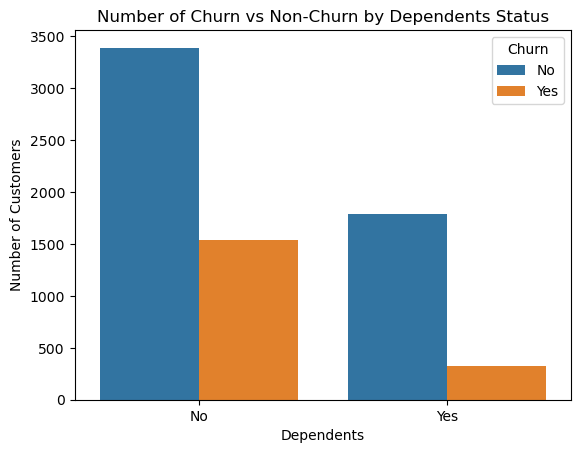

In [29]:
sns.countplot(
    data=df,
    x='Dependents',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Dependents Status')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\217568373.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


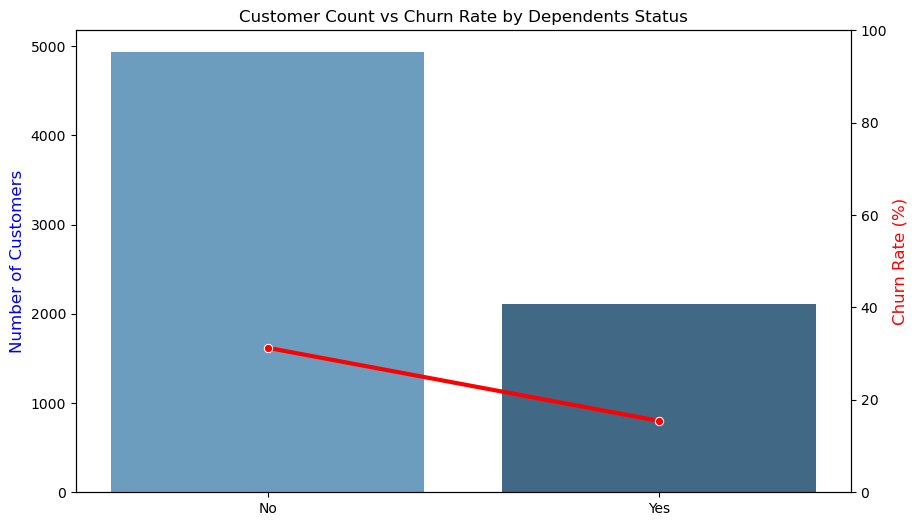

In [30]:
# 1. Setup data
data = df

kind = ['No', 'Yes']

customer = data.groupby('Dependents')['customerID'].count()

churn = (
    data.groupby('Dependents')['Churn']
    .apply(lambda x: (x == 'Yes').mean()) * 100
)

# 2. Create first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=kind,
    y=customer,
    ax=ax1,
    palette='Blues_d'
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create second Y-axis
ax2 = ax1.twinx()

# 4. Create second plot (Line Chart)
sns.lineplot(
    x=kind,
    y=churn,
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel('Churn Rate (%)', color='red', fontsize=12)

# Persentase 0–100%
ax2.set_ylim(0, 100)

plt.title('Customer Count vs Churn Rate by Dependents Status')
plt.xlabel('Dependents Status')

plt.show()

It shows a difference of around 16%, with customers who have dependents exhibiting a higher churn rate compared to those without dependents, when measured relative to their respective group sizes.

### e. Jenis contract

In [31]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [32]:
Contract_Monthly = df[df['Contract'] == 'Month-to-month']
Contract_OneYear = df[df['Contract'] == 'One year']
Contract_TwoYear = df[df['Contract'] == 'Two year']
CM_pres = len(Contract_Monthly) / len(df) * 100
OY_pres = len(Contract_OneYear) / len(df) * 100
TY_pres = len(Contract_TwoYear) / len(df) * 100
print(f'''
      Number of customers with a month-to-month contract = {len(Contract_Monthly)}, 
      Number of customers with a one-year contract = {len(Contract_OneYear)}, 
      Number of customers with a two-year contract = {len(Contract_TwoYear)}
      ''')

print(f'''
      Percentage of customers with a month-to-month contract = {CM_pres:.2f}%, 
      Percentage of customers with a one-year contract = {OY_pres:.2f}%, 
      Percentage of customers with a two-year contract = {TY_pres:.2f}%
      ''')


      Number of customers with a month-to-month contract = 3875, 
      Number of customers with a one-year contract = 1473, 
      Number of customers with a two-year contract = 1695
      

      Percentage of customers with a month-to-month contract = 55.02%, 
      Percentage of customers with a one-year contract = 20.91%, 
      Percentage of customers with a two-year contract = 24.07%
      


In [33]:
CM_Churn_Yes = Contract_Monthly[Contract_Monthly['Churn'] == 'Yes']
OY_Churn_Yes = Contract_OneYear[Contract_OneYear['Churn'] == 'Yes']
TY_Churn_Yes = Contract_TwoYear[Contract_TwoYear['Churn'] == 'Yes']
CMCY_Pres = len(CM_Churn_Yes) / len(Contract_Monthly) * 100
OYCY_Pres = len(OY_Churn_Yes) / len(Contract_OneYear) * 100
TYCY_Pres = len(TY_Churn_Yes) / len(Contract_TwoYear) * 100
print(f'''
      Number of customers with a month-to-month contract who churned = {len(CM_Churn_Yes)} from {len(Contract_Monthly)}, 
      Number of customers with a one-year contract who churned = {len(OY_Churn_Yes)} from {len(Contract_OneYear)}, 
      Number of customers with a two-year contract who churned = {len(TY_Churn_Yes)} from {len(Contract_TwoYear)}
      ''')

print(f'''
      Percentage of customers with a month-to-month contract who churned = {CMCY_Pres:.2f}%, 
      Percentage of customers with a one-year contract who churned = {OYCY_Pres:.2f}%, 
      Percentage of customers with a two-year contract who churned = {TYCY_Pres:.2f}%
      ''')


      Number of customers with a month-to-month contract who churned = 1655 from 3875, 
      Number of customers with a one-year contract who churned = 166 from 1473, 
      Number of customers with a two-year contract who churned = 48 from 1695
      

      Percentage of customers with a month-to-month contract who churned = 42.71%, 
      Percentage of customers with a one-year contract who churned = 11.27%, 
      Percentage of customers with a two-year contract who churned = 2.83%
      


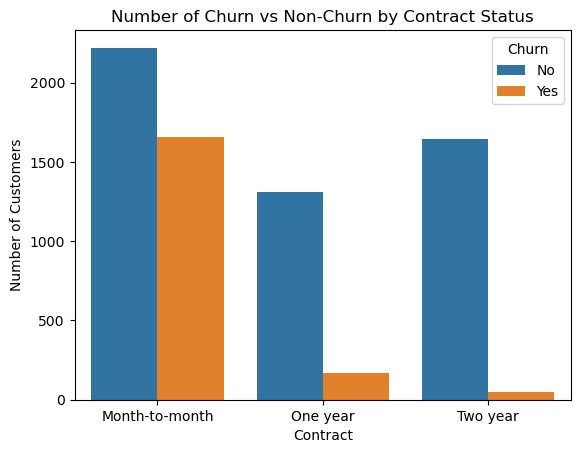

In [34]:
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Contract Status')
plt.xlabel('Contract')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\3772296416.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


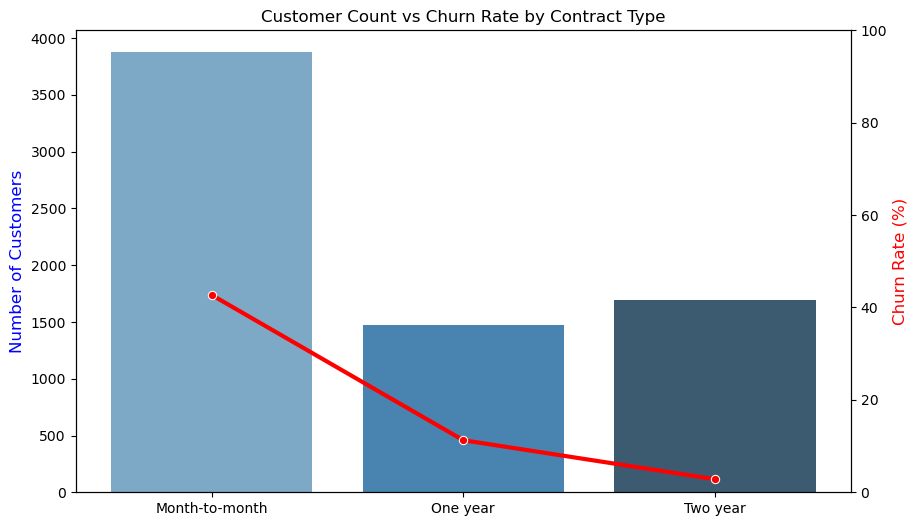

In [35]:
# 1. Setup data
data = df

kind = ['Month-to-month', 'One year', 'Two year']

customer = data.groupby('Contract')['customerID'].count()

churn = (
    data.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean()) * 100
)

# 2. Create first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=kind,
    y=customer,
    ax=ax1,
    palette='Blues_d'
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create second Y-axis
ax2 = ax1.twinx()

# 4. Create second plot (Line Chart)
sns.lineplot(
    x=kind,
    y=churn,
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel('Churn Rate (%)', color='red', fontsize=12)

# Persentase 0–100%
ax2.set_ylim(0, 100)

plt.title('Customer Count vs Churn Rate by Contract Type')
plt.xlabel('Contract Type')

plt.show()

It shows a significant difference, with a significantly higher churn percentage for month-to-month contracts at 42.71%. This is substantially higher compared to other contract types, which are only 11.27% for one-year contracts and 2.83% for two-year contracts.

### f. Payment Method

In [36]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [37]:
PM_ElectronicCheck = df[df['PaymentMethod'] == 'Electronic check']
PM_MailedCheck = df[df['PaymentMethod'] == 'Mailed check']
PM_BankTransfer = df[df['PaymentMethod'] == 'Bank transfer (automatic)']
PM_CreditCard = df[df['PaymentMethod'] == 'Credit card (automatic)']
PMEC_Pres = len(PM_ElectronicCheck) / len(df) * 100
PMMC_Pres = len(PM_MailedCheck) / len(df) * 100
PMBT_Pres = len(PM_BankTransfer) / len(df) * 100
PMCC_Pres = len(PM_CreditCard) / len(df) * 100
print(f'''
      Number of customers with electronic check payment method = {len(PM_ElectronicCheck)}, 
      Number of customers with mailed check payment method = {len(PM_MailedCheck)}, 
      Number of customers with bank transfer payment method = {len(PM_BankTransfer)}, 
      Number of customers with credit card payment method = {len(PM_CreditCard)}
      ''')

print(f'''
      Percentage of customers with electronic check payment method = {PMEC_Pres:.2f}%, 
      Percentage of customers with mailed check payment method = {PMMC_Pres:.2f}%, 
      Percentage of customers with bank transfer payment method = {PMBT_Pres:.2f}%, 
      Percentage of customers with credit card payment method = {PMCC_Pres:.2f}%
      ''')


      Number of customers with electronic check payment method = 2365, 
      Number of customers with mailed check payment method = 1612, 
      Number of customers with bank transfer payment method = 1544, 
      Number of customers with credit card payment method = 1522
      

      Percentage of customers with electronic check payment method = 33.58%, 
      Percentage of customers with mailed check payment method = 22.89%, 
      Percentage of customers with bank transfer payment method = 21.92%, 
      Percentage of customers with credit card payment method = 21.61%
      


In [38]:
PMEC_Churn_Yes = PM_ElectronicCheck[PM_ElectronicCheck['Churn'] == 'Yes']
PMMC_Churn_Yes = PM_MailedCheck[PM_MailedCheck['Churn'] == 'Yes']
PMBT_Churn_Yes = PM_BankTransfer[PM_BankTransfer['Churn'] == 'Yes']
PMCC_Churn_Yes = PM_CreditCard[PM_CreditCard['Churn'] == 'Yes']
PMECCY_Pres = len(PMEC_Churn_Yes) / len(PM_ElectronicCheck) * 100
PMMCCY_Pres = len(PMMC_Churn_Yes) / len(PM_MailedCheck) * 100
PMBTCY_Pres = len(PMBT_Churn_Yes) / len(PM_BankTransfer) * 100
PMCCCY_Pres = len(PMCC_Churn_Yes) / len(PM_CreditCard) * 100
print(f'''
      Number of customers with electronic check payment method who churned = {len(PMEC_Churn_Yes)} from {len(PM_ElectronicCheck)}, 
      Number of customers with mailed check payment method who churned = {len(PMMC_Churn_Yes)} from {len(PM_MailedCheck)}, 
      Number of customers with bank transfer payment method who churned = {len(PMBT_Churn_Yes)} from {len(PM_BankTransfer)}, 
      Number of customers with credit card payment method who churned = {len(PMCC_Churn_Yes)} from {len(PM_CreditCard)}
      ''')

print(f'''
      Percentage of customers with electronic check payment method who churned = {PMECCY_Pres:.2f}%, 
      Percentage of customers with mailed check payment method who churned = {PMMCCY_Pres:.2f}%, 
      Percentage of customers with bank transfer payment method who churned = {PMBTCY_Pres:.2f}%, 
      Percentage of customers with credit card payment method who churned = {PMCCCY_Pres:.2f}%
      ''')


      Number of customers with electronic check payment method who churned = 1071 from 2365, 
      Number of customers with mailed check payment method who churned = 308 from 1612, 
      Number of customers with bank transfer payment method who churned = 258 from 1544, 
      Number of customers with credit card payment method who churned = 232 from 1522
      

      Percentage of customers with electronic check payment method who churned = 45.29%, 
      Percentage of customers with mailed check payment method who churned = 19.11%, 
      Percentage of customers with bank transfer payment method who churned = 16.71%, 
      Percentage of customers with credit card payment method who churned = 15.24%
      


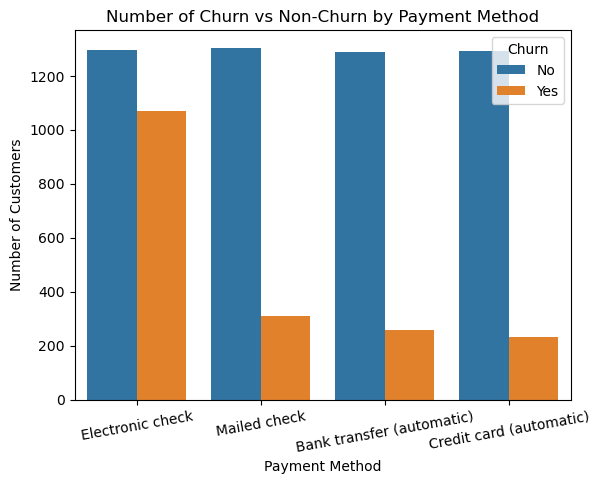

In [39]:
sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=10)
plt.show()

In [40]:
customer

Contract
Month-to-month    3875
One year          1473
Two year          1695
Name: customerID, dtype: int64

In [41]:
data.groupby('PaymentMethod').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

,PaymentMethod,Churn,customerID
0,Bank transfer (automatic),16.709845,1544
1,Credit card (automatic),15.243101,1522
2,Electronic check,45.285412,2365
3,Mailed check,19.106700,1612


C:\Users\User\AppData\Local\Temp\ipykernel_37948\812442947.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


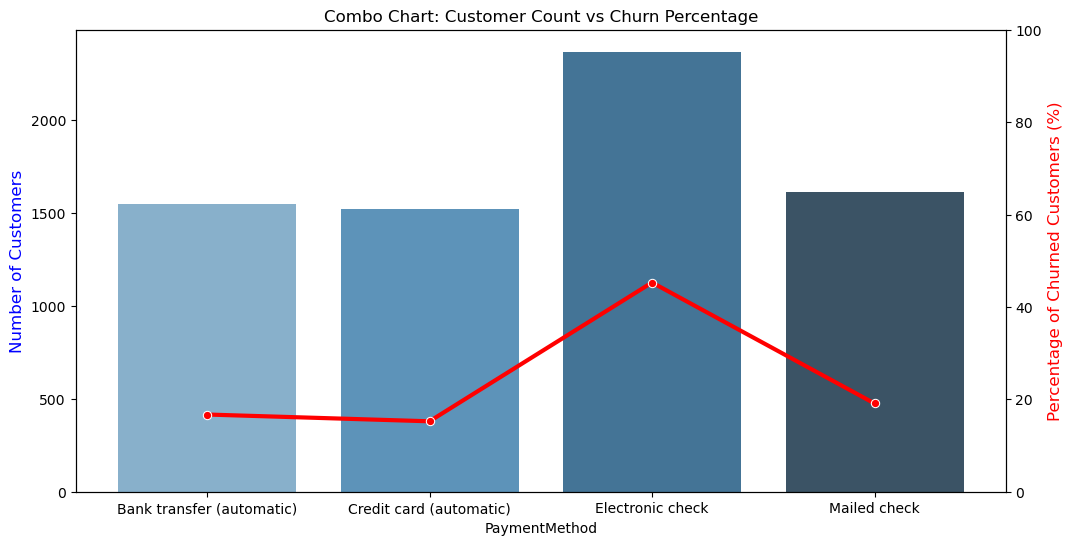

In [42]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('PaymentMethod').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['PaymentMethod'].unique()

# customer = data.groupby('PaymentMethod')['customerID'].count()

# churn = (
#     data.groupby('PaymentMethod')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=aggregated_data['PaymentMethod'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['PaymentMethod'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Payment Method')

# Rotasi label biar tidak tabrakan
plt.xticks(rotation=10)

plt.show()

In [43]:
churn.reset_index()

,Contract,Churn
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


There is a significant difference in churn for customers using the electronic check payment method, with a rate of 45.29%.

## 3. What is the churn rate based on product services (phone service, multiple lines, streaming TV, and streaming movies)?

### a. Phone Service

In [44]:
PS_Yes = df[df['PhoneService'] == 'Yes']
PS_No = df[df['PhoneService'] == 'No'] 
PSY_Pres = len(PS_Yes) / len(df) * 100
PSN_Pres = len(PS_No) / len(df) * 100
print(f'Number of customers who have phone service = {len(PS_Yes)}, Number of customers who do not have phone service = {len(PS_No)}')
print(f'Percentage of customers who have phone service = {PSY_Pres:.2f}%, Percentage of customers who do not have phone service = {PSN_Pres:.2f}%')

Number of customers who have phone service = 6361, Number of customers who do not have phone service = 682
Percentage of customers who have phone service = 90.32%, Percentage of customers who do not have phone service = 9.68%


In [45]:
PSY_Churn_Yes = PS_Yes[PS_Yes['Churn'] == 'Yes']
PSN_Churn_Yes = PS_No[PS_No['Churn'] == 'Yes']
PSYCY_Pres = len(PSY_Churn_Yes) / len(PS_Yes) * 100
PSNCY_Pres = len(PSN_Churn_Yes) / len(PS_No) * 100
print(f'''
      Number of customers who use phone service and churned = {len(PSY_Churn_Yes)} from {len(PS_Yes)}, 
      Number of customers who do not use phone service and churned = {len(PSN_Churn_Yes)} from {len(PS_No)}
      ''')

print(f'''
      Percentage of customers who use phone service and churned = {PSYCY_Pres:.2f}%, 
      Percentage of customers who do not use phone service and churned = {PSNCY_Pres:.2f}%
      ''')


      Number of customers who use phone service and churned = 1699 from 6361, 
      Number of customers who do not use phone service and churned = 170 from 682
      

      Percentage of customers who use phone service and churned = 26.71%, 
      Percentage of customers who do not use phone service and churned = 24.93%
      


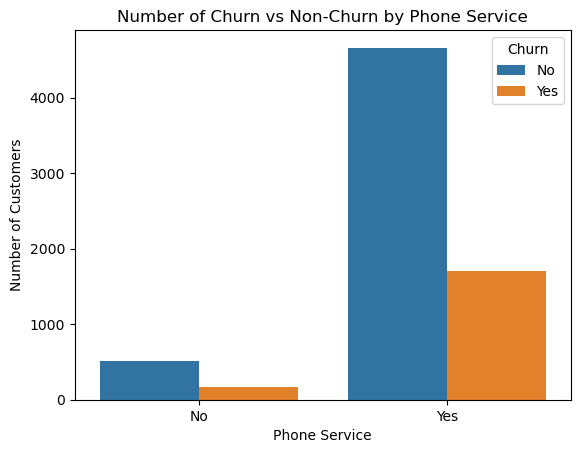

In [46]:
sns.countplot(
    data=df,
    x='PhoneService',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Phone Service')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\1939820435.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


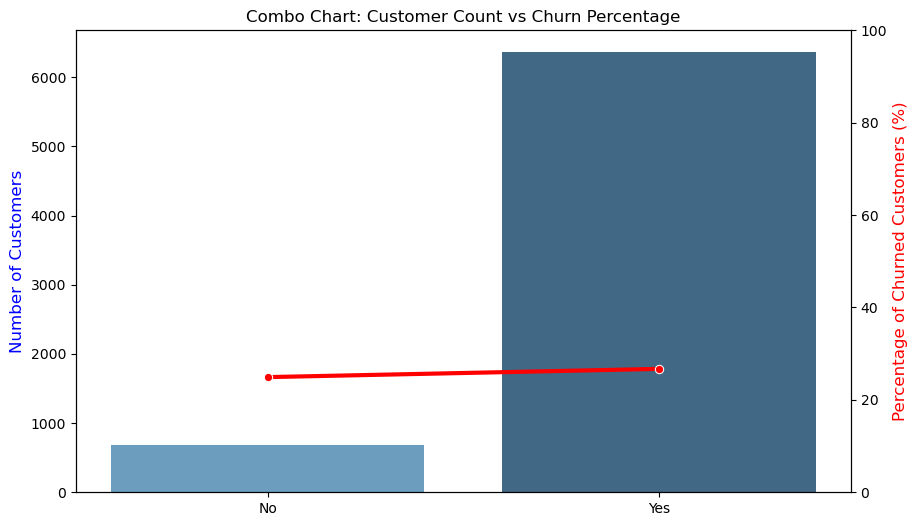

In [47]:
# 1. Setup your data
data = df

kind = data['PhoneService'].unique()

customer = data.groupby('PhoneService')['customerID'].count()

churn = (
    data.groupby('PhoneService')['Churn']
    .apply(lambda x: (x == 'Yes').mean()) * 100
)

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=kind,
    y=customer,
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0-100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=kind,
    y=churn,
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Phone Service')

plt.show()

There is no significant difference in churn between customers who use the phone service and not use the phone service when compared relative to their respective group sizes. However, in terms of volume, the number of churned customers who use the phone service is higher (1,699 customers) compared to those who do not (170 customers), although the churn percentages between the two groups are nearly the same, who use the phone service (26.71%) and do not use (24.93%).


### b. Multiple Lines

In [48]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [49]:
ML_No = df[df['MultipleLines'] == 'No']
ML_Yes = df[df['MultipleLines'] == 'Yes']
ML_NoPS = df[df['MultipleLines'] == 'No phone service']
MLN_Pres = len(ML_No) / len(df) * 100
MLY_Pres = len(ML_Yes) / len(df) * 100
MLNPS_Pres = len(ML_NoPS) / len(df) * 100
print(f'''
      Number of customers who do not use multiple lines = {len(ML_No)}, 
      Number of customers who use multiple lines = {len(ML_Yes)}, 
      Number of customers who do not use phone service = {len(ML_NoPS)}
      ''')

print(f'''
      Percentage of customers who do not use multiple lines = {MLN_Pres:.2f}%, 
      Percentage of customers who use multiple lines = {MLY_Pres:.2f}%, 
      Percentage of customers who do not use phone service = {MLNPS_Pres:.2f}%
      ''')


      Number of customers who do not use multiple lines = 3390, 
      Number of customers who use multiple lines = 2971, 
      Number of customers who do not use phone service = 682
      

      Percentage of customers who do not use multiple lines = 48.13%, 
      Percentage of customers who use multiple lines = 42.18%, 
      Percentage of customers who do not use phone service = 9.68%
      


In [50]:
MLN_Churn_Yes = ML_No[ML_No['Churn'] == 'Yes']
MLY_Churn_Yes = ML_Yes[ML_Yes['Churn'] == 'Yes']
MLNPS_Churn_Yes = ML_NoPS[ML_NoPS['Churn'] == 'Yes']
MLNCY_Pres = len(MLN_Churn_Yes) / len(ML_No) * 100
MLYCY_Pres = len(MLY_Churn_Yes) / len(ML_Yes) * 100
MLNPSCY_Pres = len(MLNPS_Churn_Yes) / len(ML_NoPS) * 100
print(f'''
      Number of customers who do not use multiple lines and churned = {len(MLN_Churn_Yes)} from {len(ML_No)}, 
      Number of customers who use multiple lines and churned = {len(MLY_Churn_Yes)} from {len(ML_Yes)}, 
      Number of customers who do not use phone service and churned = {len(MLNPS_Churn_Yes)} from {len(ML_NoPS)}
      ''')

print(f'''
      Percentage of customers who do not use multiple lines and churned = {MLNCY_Pres:.2f}%, 
      Percentage of customers who use multiple lines and churned = {MLYCY_Pres:.2f}%, 
      Percentage of customers who do not use phone service and churned = {MLNPSCY_Pres:.2f}%
      ''')


      Number of customers who do not use multiple lines and churned = 849 from 3390, 
      Number of customers who use multiple lines and churned = 850 from 2971, 
      Number of customers who do not use phone service and churned = 170 from 682
      

      Percentage of customers who do not use multiple lines and churned = 25.04%, 
      Percentage of customers who use multiple lines and churned = 28.61%, 
      Percentage of customers who do not use phone service and churned = 24.93%
      


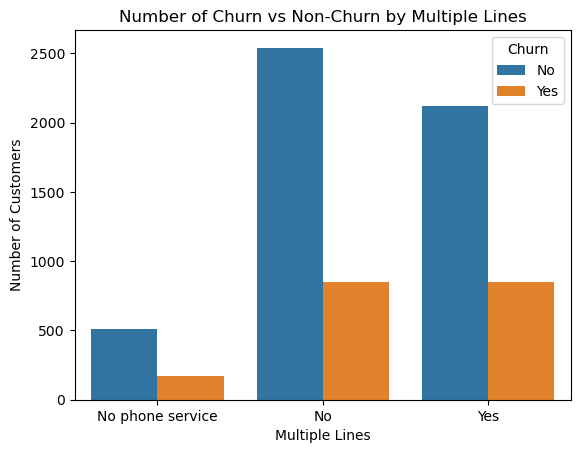

In [51]:
sns.countplot(
    data=df,
    x='MultipleLines',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Multiple Lines')
plt.xlabel('Multiple Lines')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\4096584155.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


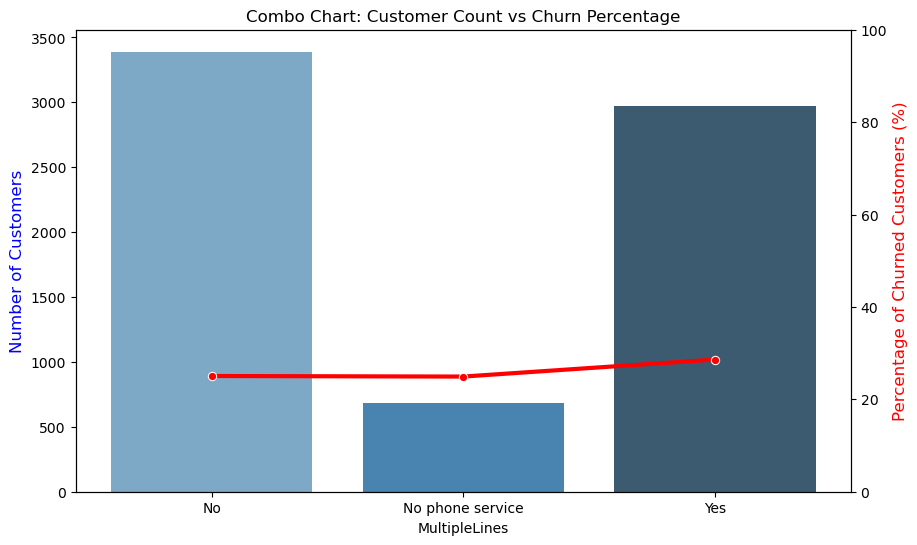

In [52]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('MultipleLines').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['MultipleLines'].unique()

# customer = data.groupby('MultipleLines')['customerID'].count()

# churn = (
#     data.groupby('MultipleLines')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['MultipleLines'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['MultipleLines'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Multiple Lines')

plt.show()

There is no significant difference in churn between customers who have phone service and those who do not have phone service.

### c. Streaming TV

In [53]:
STV_No = df[df['StreamingTV'] == 'No']
STV_Yes = df[df['StreamingTV'] == 'Yes']
STV_NoIS = df[df['StreamingTV'] == 'No internet service']
STV_No_Pres = len(STV_No) / len(df) * 100
STV_Yes_Pres = len(STV_Yes) / len(df) * 100
STV_NoIS_Pres = len(STV_NoIS) / len(df) * 100
print(f'''
      Number of customers who do not use streaming TV = {len(STV_No)}, 
      Number of customers who use streaming TV = {len(STV_Yes)},
      Number of customers who do not have internet service for streaming TV = {len(STV_NoIS)}
      ''')

print(f'''
      Percentage of customers who do not use streaming TV = {STV_No_Pres:.2f}%, 
      Percentage of customers who use streaming TV = {STV_Yes_Pres:.2f}%,
      Percentage of customers who do not have internet service for streaming TV = {STV_NoIS_Pres:.2f}%
      ''')


      Number of customers who do not use streaming TV = 2810, 
      Number of customers who use streaming TV = 2707,
      Number of customers who do not have internet service for streaming TV = 1526
      

      Percentage of customers who do not use streaming TV = 39.90%, 
      Percentage of customers who use streaming TV = 38.44%,
      Percentage of customers who do not have internet service for streaming TV = 21.67%
      


In [54]:
STVNo_Churn_Yes = STV_No[STV_No['Churn'] == 'Yes']
STVYes_Churn_Yes = STV_Yes[STV_Yes['Churn'] == 'Yes']
STVNoIS_Churn_Yes = STV_NoIS[STV_NoIS['Churn'] == 'Yes']
STVNoCY_Pres = len(STVNo_Churn_Yes) / len(STV_No) * 100
STVYesCY_Pres = len(STVYes_Churn_Yes) / len(STV_Yes) * 100
STVNoISCY_Pres = len(STVNoIS_Churn_Yes) / len(STV_NoIS) * 100
print(f'''
        Number of customers who do not use streaming TV and churned = {len(STVNo_Churn_Yes)} from {len(STV_No)}, 
        Number of customers who use streaming TV and churned = {len(STVYes_Churn_Yes)} from {len(STV_Yes)}, 
        Number of customers who do not have internet service for streaming TV and churned = {len(STVNoIS_Churn_Yes)} from {len(STV_NoIS)}
        ''')

print(f'''
        Percentage of customers who do not use streaming TV and churned = {STVNoCY_Pres:.2f}%, 
        Percentage of customers who use streaming TV and churned = {STVYesCY_Pres:.2f}%, 
        Percentage of customers who do not have internet service for streaming TV and churned = {STVNoISCY_Pres:.2f}%
        ''')


        Number of customers who do not use streaming TV and churned = 942 from 2810, 
        Number of customers who use streaming TV and churned = 814 from 2707, 
        Number of customers who do not have internet service for streaming TV and churned = 113 from 1526
        

        Percentage of customers who do not use streaming TV and churned = 33.52%, 
        Percentage of customers who use streaming TV and churned = 30.07%, 
        Percentage of customers who do not have internet service for streaming TV and churned = 7.40%
        


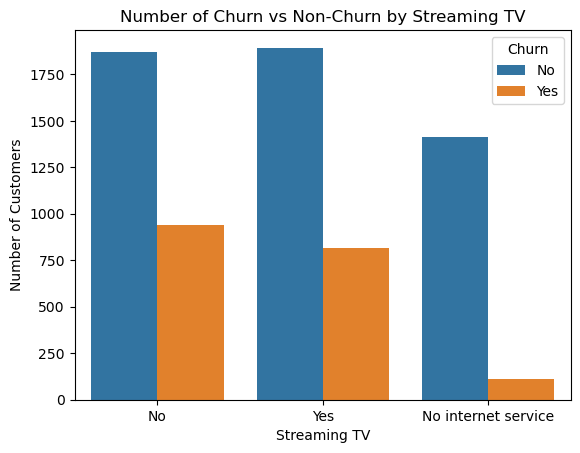

In [55]:
sns.countplot(
    data=df,
    x='StreamingTV',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Streaming TV')
plt.xlabel('Streaming TV')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\2787793735.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


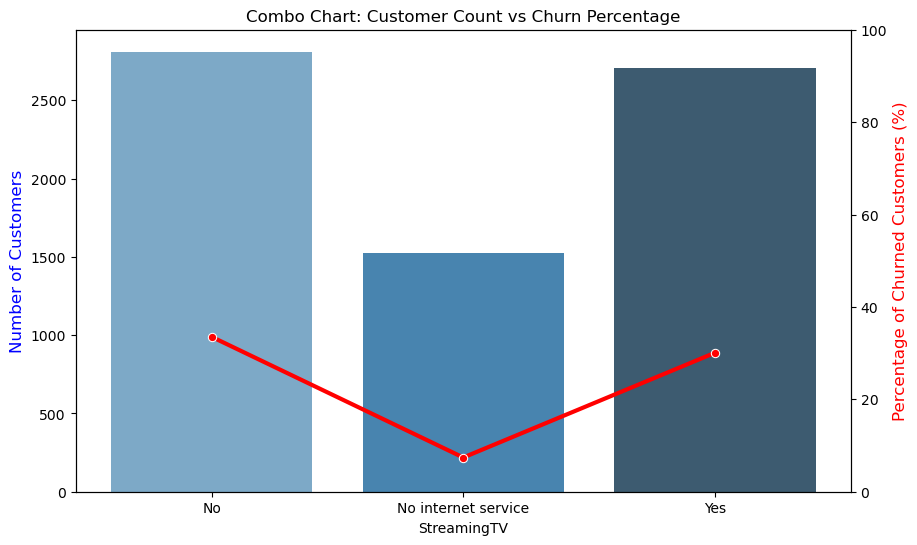

In [56]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('StreamingTV').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()
# kind = data['StreamingTV'].unique()

# customer = data.groupby('StreamingTV')['customerID'].count()

# churn = (
#     data.groupby('StreamingTV')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['StreamingTV'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['StreamingTV'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Streaming TV')

plt.show()

There is a higher churn observed among customers who use Streaming TV (30.07%) and those who do not use Streaming TV (33.52%) compared to customers who do not have internet service for Streaming TV (7.40%). However, there is no significant difference between the churn percentages of customers who use Streaming TV and those who do not.

### d. Streaming Movies

In [57]:
df['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [58]:
SMV_No = df[df['StreamingMovies'] == 'No']
SMV_Yes = df[df['StreamingMovies'] == 'Yes']
SMV_NoIS = df[df['StreamingMovies'] == 'No internet service']
SMV_No_Pres = len(SMV_No) / len(df) * 100
SMV_Yes_Pres = len(SMV_Yes) / len(df) * 100
SMV_NoIS_Pres = len(SMV_NoIS) / len(df) * 100
print(f'''
        Number of customers who do not use streaming movies = {len(SMV_No)}, 
        Number of customers who use streaming movies = {len(SMV_Yes)},
        Number of customers who do not have internet service for streaming movies = {len(SMV_NoIS)}
        ''')

print(f'''
        Percentage of customers who do not use streaming movies = {SMV_No_Pres:.2f}%, 
        Percentage of customers who use streaming movies = {SMV_Yes_Pres:.2f}%,
        Percentage of customers who do not have internet service for streaming movies = {SMV_NoIS_Pres:.2f}%
        ''')



        Number of customers who do not use streaming movies = 2785, 
        Number of customers who use streaming movies = 2732,
        Number of customers who do not have internet service for streaming movies = 1526
        

        Percentage of customers who do not use streaming movies = 39.54%, 
        Percentage of customers who use streaming movies = 38.79%,
        Percentage of customers who do not have internet service for streaming movies = 21.67%
        


In [59]:
SMVNo_Churn_Yes = SMV_No[SMV_No['Churn'] == 'Yes']
SMVYes_Churn_Yes = SMV_Yes[SMV_Yes['Churn'] == 'Yes']
SMVNoIS_Churn_Yes = SMV_NoIS[SMV_NoIS['Churn'] == 'Yes']
SMVNoCY_Pres = len(SMVNo_Churn_Yes) / len(SMV_No) * 100
SMVYesCY_Pres = len(SMVYes_Churn_Yes) / len(SMV_Yes) * 100
SMVNoISCY_Pres = len(SMVNoIS_Churn_Yes) / len(SMV_NoIS) * 100
print(f'''
        Number of customers who do not use streaming movies and churned = {len(SMVNo_Churn_Yes)} from {len(SMV_No)}, 
        Number of customers who use streaming movies and churned = {len(SMVYes_Churn_Yes)} from {len(SMV_Yes)}, 
        Number of customers who do not have internet service for streaming movies and churned = {len(SMVNoIS_Churn_Yes)} from {len(SMV_NoIS)}
        ''')

print(f'''
        Percentage of customers who do not use streaming movies and churned = {SMVNoCY_Pres:.2f}%, 
        Percentage of customers who use streaming movies and churned = {SMVYesCY_Pres:.2f}%, 
        Percentage of customers who do not have internet service for streaming movies and churned = {SMVNoISCY_Pres:.2f}%
        ''')


        Number of customers who do not use streaming movies and churned = 938 from 2785, 
        Number of customers who use streaming movies and churned = 818 from 2732, 
        Number of customers who do not have internet service for streaming movies and churned = 113 from 1526
        

        Percentage of customers who do not use streaming movies and churned = 33.68%, 
        Percentage of customers who use streaming movies and churned = 29.94%, 
        Percentage of customers who do not have internet service for streaming movies and churned = 7.40%
        


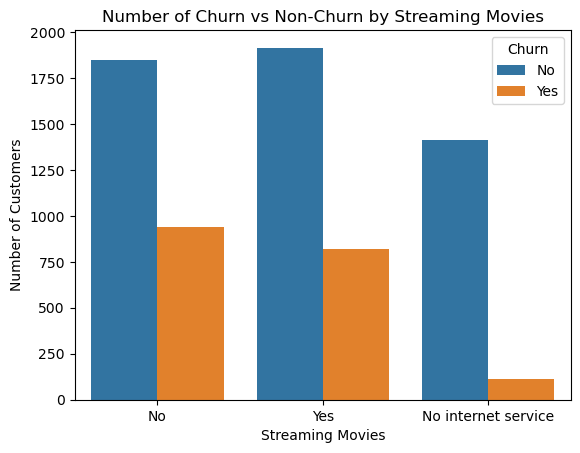

In [60]:
sns.countplot(
    data=df,
    x='StreamingMovies',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Streaming Movies')
plt.xlabel('Streaming Movies')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\443399756.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


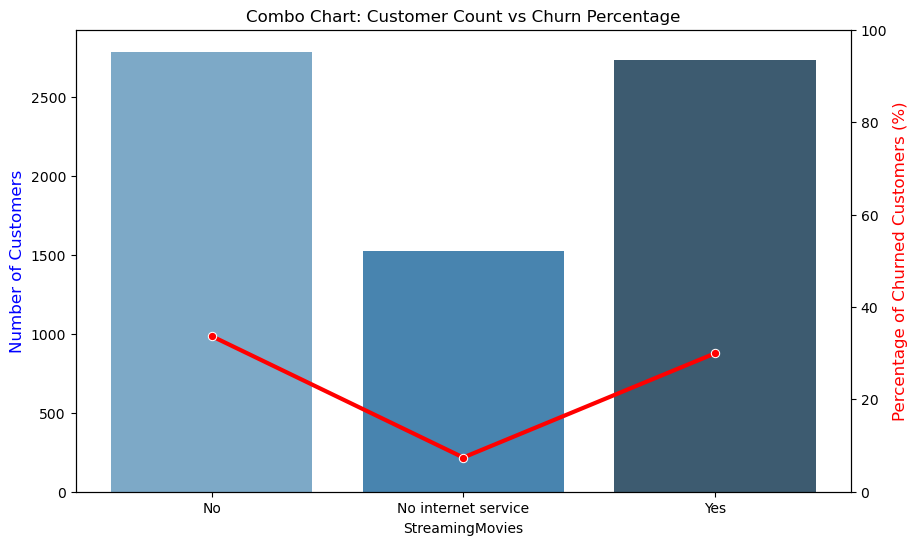

In [61]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('StreamingMovies').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['StreamingMovies'].unique()

# customer = data.groupby('StreamingMovies')['customerID'].count()

# churn = (
#     data.groupby('StreamingMovies')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['StreamingMovies'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['StreamingMovies'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Streaming Movies')

plt.show()

It shows a higher churn percentage among customers who do not use streaming movies at 33.68%, followed by those who use streaming movies at 29.94%. However, there is no significant difference between the churn percentages of customers who use streaming movies and customers without the service.

## 4. What is the churn percentage across each security add-on service (Online Security, Online Backup, Device Protection, and Tech Support)?

### a. Online Security

In [62]:
OS_No = df[df['OnlineSecurity'] == 'No']
OS_Yes = df[df['OnlineSecurity'] == 'Yes']
OS_NoIS = df[df['OnlineSecurity'] == 'No internet service']
OS_No_Pres = len(OS_No) / len(df) * 100
OS_Yes_Pres = len(OS_Yes) / len(df) * 100
OS_NoIS_Pres = len(OS_NoIS) / len(df) * 100
print(f'''
        Number of customers who do not use online security = {len(OS_No)}, 
        Number of customers who use online security = {len(OS_Yes)},
        Number of customers who do not have internet service for online security = {len(OS_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use online security = {OS_No_Pres:.2f}%, 
        Percentage of customers who use online security = {OS_Yes_Pres:.2f}%,
        Percentage of customers who do not have internet service for online security = {OS_NoIS_Pres:.2f}%
        ''')


        Number of customers who do not use online security = 3498, 
        Number of customers who use online security = 2019,
        Number of customers who do not have internet service for online security = 1526
        

        Percentage of customers who do not use online security = 49.67%, 
        Percentage of customers who use online security = 28.67%,
        Percentage of customers who do not have internet service for online security = 21.67%
        


In [63]:
OSNo_Churn_Yes = OS_No[OS_No['Churn'] == 'Yes']
OSYes_Churn_Yes = OS_Yes[OS_Yes['Churn'] == 'Yes']
OSNoIS_Churn_Yes = OS_NoIS[OS_NoIS['Churn'] == 'Yes']
OSNoCY_Pres = len(OSNo_Churn_Yes) / len(OS_No) * 100
OSYesCY_Pres = len(OSYes_Churn_Yes) / len(OS_Yes) * 100
OSNoISCY_Pres = len(OSNoIS_Churn_Yes) / len(OS_NoIS) * 100
print(f'''
        Number of customers who do not use online security and churned = {len(OSNo_Churn_Yes)} from {len(OS_No)}, 
        Number of customers who use online security and churned = {len(OSYes_Churn_Yes)} from {len(OS_Yes)}, 
        Number of customers who do not have internet service for online security and churned = {len(OSNoIS_Churn_Yes)} from {len(OS_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use online security and churn = {OSNoCY_Pres:.2f}%, 
        Percentage of customers who use online security and churn = {OSYesCY_Pres:.2f}%,
        Percentage of customers who do not have internet service for online security and churn = {OSNoISCY_Pres:.2f}%
        ''')



        Number of customers who do not use online security and churned = 1461 from 3498, 
        Number of customers who use online security and churned = 295 from 2019, 
        Number of customers who do not have internet service for online security and churned = 113 from 1526
        

        Percentage of customers who do not use online security and churn = 41.77%, 
        Percentage of customers who use online security and churn = 14.61%,
        Percentage of customers who do not have internet service for online security and churn = 7.40%
        


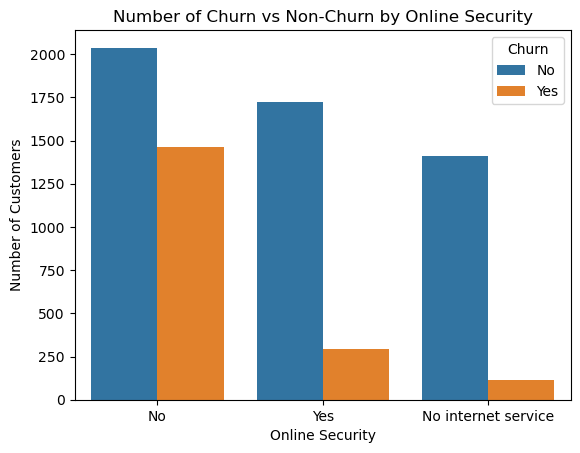

In [64]:
sns.countplot(
    data=df,
    x='OnlineSecurity',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\2634616266.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


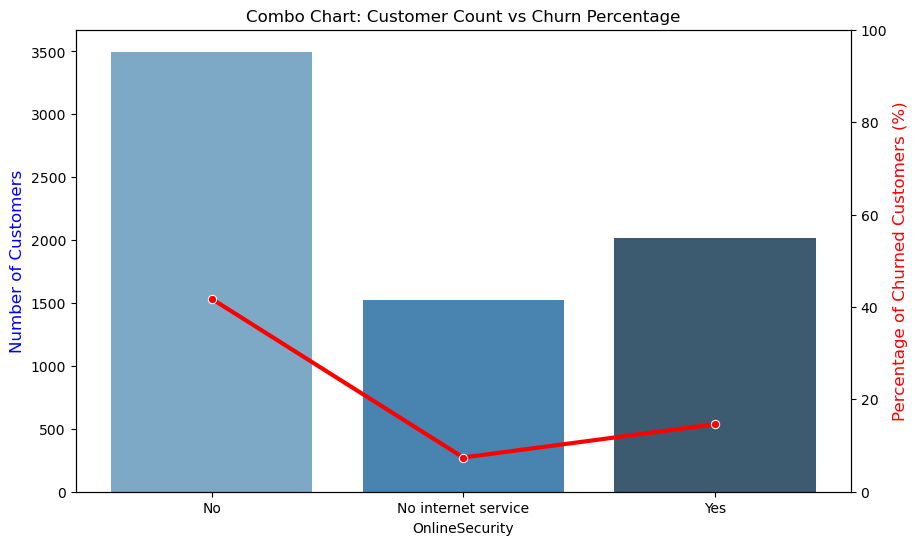

In [65]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('OnlineSecurity').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['OnlineSecurity'].unique()

# customer = data.groupby('OnlineSecurity')['customerID'].count()

# churn = (
#     data.groupby('OnlineSecurity')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['OnlineSecurity'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['OnlineSecurity'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Online Security')

plt.show()

It shows the higher churn is who do not use the Online Security add-ons service, around 41.77%. 

### b. Online Backup

In [66]:
OB_No = df[df['OnlineBackup'] == 'No']
OB_Yes = df[df['OnlineBackup'] == 'Yes']
OB_NoIS = df[df['OnlineBackup'] == 'No internet service']
OB_No_Pres = len(OB_No) / len(df) * 100
OB_Yes_Pres = len(OB_Yes) / len(df) * 100
OB_NoIS_Pres = len(OB_NoIS) / len(df) * 100
print(f'''
        Number of customers who do not use online backup = {len(OB_No)}, 
        Number of customers who use online backup = {len(OB_Yes)},
        Number of customers who do not have internet service for online backup = {len(OB_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use online backup = {OB_No_Pres:.2f}%, 
        Percentage of customers who use online backup = {OB_Yes_Pres:.2f}%,
        Percentage of customers who do not have internet service for online backup = {OB_NoIS_Pres:.2f}%
        ''')


        Number of customers who do not use online backup = 3088, 
        Number of customers who use online backup = 2429,
        Number of customers who do not have internet service for online backup = 1526
        

        Percentage of customers who do not use online backup = 43.84%, 
        Percentage of customers who use online backup = 34.49%,
        Percentage of customers who do not have internet service for online backup = 21.67%
        


In [67]:
OBYes_Churn_Yes = OB_Yes[OB_Yes['Churn'] == 'Yes']
OBNo_Churn_Yes = OB_No[OB_No['Churn'] == 'Yes']
OBNoIS_Churn_Yes = OB_NoIS[OB_NoIS['Churn'] == 'Yes']
OBYesCY_Pres = len(OBYes_Churn_Yes) / len(OB_Yes) * 100
OBNoCY_Pres = len(OBNo_Churn_Yes) / len(OB_No) * 100
OBNoISCY_Pres = len(OBNoIS_Churn_Yes) / len(OB_NoIS) * 100
print(f'''
        Number of customers who use online backup and churned = {len(OBYes_Churn_Yes)} from {len(OB_Yes)}, 
        Number of customers who do not use online backup and churned = {len(OBNo_Churn_Yes)} from {len(OB_No)}, 
        Number of customers who do not have internet service for online backup and churned = {len(OBNoIS_Churn_Yes)} from {len(OB_NoIS)}
        ''')
print(f'''
        Percentage of customers who use online backup and churn = {OBYesCY_Pres:.2f}%, 
        Percentage of customers who do not use online backup and churn = {OBNoCY_Pres:.2f}%,
        Percentage of customers who do not have internet service for online backup and churn = {OBNoISCY_Pres:.2f}%
        ''')


        Number of customers who use online backup and churned = 523 from 2429, 
        Number of customers who do not use online backup and churned = 1233 from 3088, 
        Number of customers who do not have internet service for online backup and churned = 113 from 1526
        

        Percentage of customers who use online backup and churn = 21.53%, 
        Percentage of customers who do not use online backup and churn = 39.93%,
        Percentage of customers who do not have internet service for online backup and churn = 7.40%
        


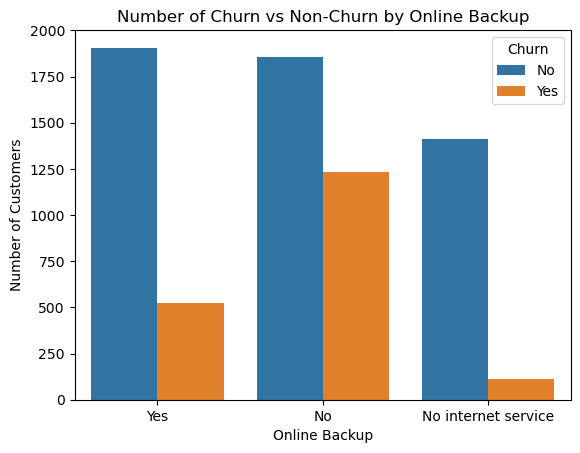

In [68]:
sns.countplot(
    data=df,
    x='OnlineBackup',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Online Backup')
plt.xlabel('Online Backup')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\3533082053.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


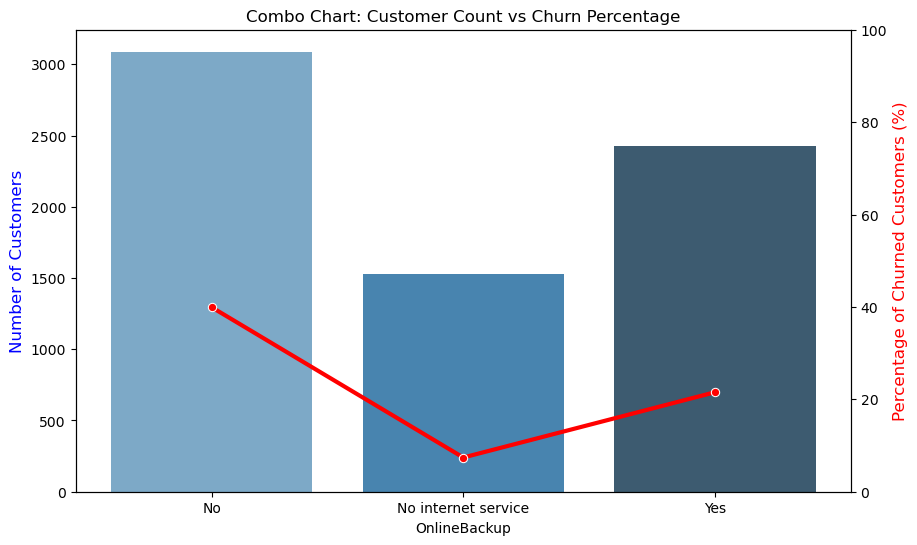

In [69]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('OnlineBackup').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['OnlineBackup'].unique()

# customer = data.groupby('OnlineBackup')['customerID'].count()

# churn = (
#     data.groupby('OnlineBackup')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['OnlineBackup'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['OnlineBackup'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Online Backup')

plt.show()

It shows the higher churn is customers who do not use the Online Backup add-ons service, around 39.93%.

### c. Device Protection

In [70]:
DP_No = df[df['DeviceProtection'] == 'No']
DP_Yes = df[df['DeviceProtection'] == 'Yes']
DP_NoIS = df[df['DeviceProtection'] == 'No internet service']
DP_No_Pres = len(DP_No) / len(df) * 100
DP_Yes_Pres = len(DP_Yes) / len(df) * 100
DP_NoIS_Pres = len(DP_NoIS) / len(df) * 100
print(f'''
        Number of customers who do not use device protection = {len(DP_No)}, 
        Number of customers who use device protection = {len(DP_Yes)},
        Number of customers who do not have internet service for device protection = {len(DP_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use device protection = {DP_No_Pres:.2f}%, 
        Percentage of customers who use device protection = {DP_Yes_Pres:.2f}%,
        Percentage of customers who do not have internet service for device protection = {DP_NoIS_Pres:.2f}%
        ''')


        Number of customers who do not use device protection = 3095, 
        Number of customers who use device protection = 2422,
        Number of customers who do not have internet service for device protection = 1526
        

        Percentage of customers who do not use device protection = 43.94%, 
        Percentage of customers who use device protection = 34.39%,
        Percentage of customers who do not have internet service for device protection = 21.67%
        


In [71]:
DPNo_Churn_Yes = DP_No[DP_No['Churn'] == 'Yes']
DPYes_Churn_Yes = DP_Yes[DP_Yes['Churn'] == 'Yes']
DPNoIS_Churn_Yes = DP_NoIS[DP_NoIS['Churn'] == 'Yes']
DPNoCY_Pres = len(DPNo_Churn_Yes) / len(DP_No) * 100
DPYesCY_Pres = len(DPYes_Churn_Yes) / len(DP_Yes) * 100
DPNoISCY_Pres = len(DPNoIS_Churn_Yes) / len(DP_NoIS) * 100
print(f'''
        Number of customers who do not use device protection and churned = {len(DPNo_Churn_Yes)} from {len(DP_No)}, 
        Number of customers who use device protection and churned = {len(DPYes_Churn_Yes)} from {len(DP_Yes)}, 
        Number of customers who do not have internet service for device protection and churned = {len(DPNoIS_Churn_Yes)} from {len(DP_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use device protection and churn = {DPNoCY_Pres:.2f}%, 
        Percentage of customers who use device protection and churn = {DPYesCY_Pres:.2f}%,
        Percentage of customers who do not have internet service for device protection and churn = {DPNoISCY_Pres:.2f}%
        ''')


        Number of customers who do not use device protection and churned = 1211 from 3095, 
        Number of customers who use device protection and churned = 545 from 2422, 
        Number of customers who do not have internet service for device protection and churned = 113 from 1526
        

        Percentage of customers who do not use device protection and churn = 39.13%, 
        Percentage of customers who use device protection and churn = 22.50%,
        Percentage of customers who do not have internet service for device protection and churn = 7.40%
        


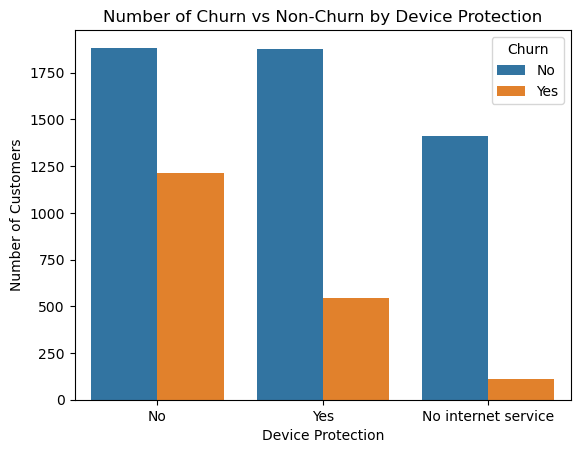

In [72]:
sns.countplot(
    data=df,
    x='DeviceProtection',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Device Protection')
plt.xlabel('Device Protection')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\2578202532.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


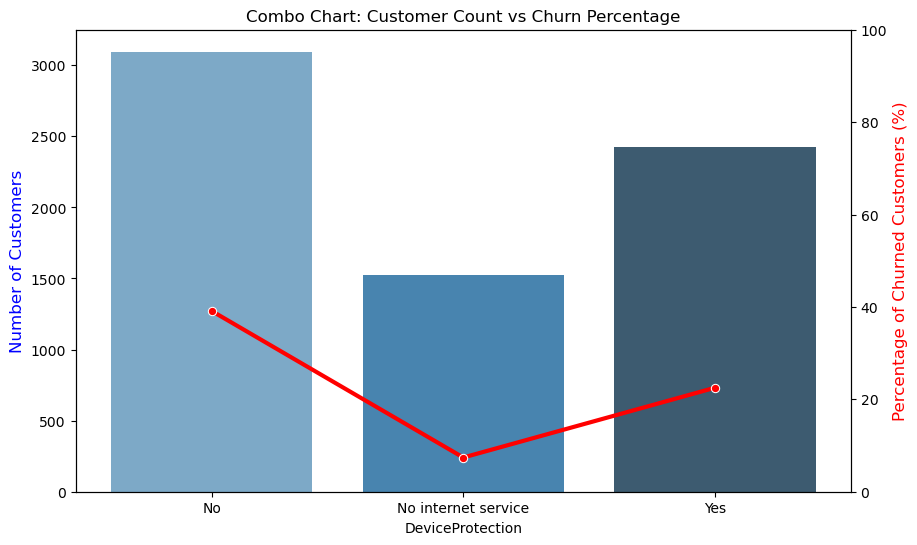

In [73]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('DeviceProtection').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['DeviceProtection'].unique()

# customer = data.groupby('DeviceProtection')['customerID'].count()

# churn = (
#     data.groupby('DeviceProtection')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['DeviceProtection'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['DeviceProtection'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Device Protection')

plt.show()

It shows the higher churn is customers who do not use the Device Protection add-ons service, around 39.13%.

### d. Tech Support

In [74]:
df['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [75]:
TS_No = df[df['TechSupport'] == 'No']
TS_Yes = df[df['TechSupport'] == 'Yes']
TS_NoIS = df[df['TechSupport'] == 'No internet service']
TS_No_Pres = len(TS_No) / len(df) * 100
TS_Yes_Pres = len(TS_Yes) / len(df) * 100
TS_NoIS_Pres = len(TS_NoIS) / len(df) * 100
print(f'''
        Number of customers who do not use tech support = {len(TS_No)}, 
        Number of customers who use tech support = {len(TS_Yes)},
        Number of customers who do not have internet service for tech support = {len(TS_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use tech support = {TS_No_Pres:.2f}%, 
        Percentage of customers who use tech support = {TS_Yes_Pres:.2f}%,
        Percentage of customers who do not have internet service for tech support = {TS_NoIS_Pres:.2f}%
        ''')


        Number of customers who do not use tech support = 3473, 
        Number of customers who use tech support = 2044,
        Number of customers who do not have internet service for tech support = 1526
        

        Percentage of customers who do not use tech support = 49.31%, 
        Percentage of customers who use tech support = 29.02%,
        Percentage of customers who do not have internet service for tech support = 21.67%
        


In [76]:
TSNo_Churn_Yes = TS_No[TS_No['Churn'] == 'Yes']
TSYes_Churn_Yes = TS_Yes[TS_Yes['Churn'] == 'Yes']
TSNoIS_Churn_Yes = TS_NoIS[TS_NoIS['Churn'] == 'Yes']
TSNoCY_Pres = len(TSNo_Churn_Yes) / len(TS_No) * 100
TSYesCY_Pres = len(TSYes_Churn_Yes) / len(TS_Yes) * 100
TSNoISCY_Pres = len(TSNoIS_Churn_Yes) / len(TS_NoIS) * 100
print(f'''
        Number of customers who do not use tech support and churned = {len(TSNo_Churn_Yes)} from {len(TS_No)}, 
        Number of customers who use tech support and churned = {len(TSYes_Churn_Yes)} from {len(TS_Yes)}, 
        Number of customers who do not have internet service for tech support and churned = {len(TSNoIS_Churn_Yes)} from {len(TS_NoIS)}
        ''')
print(f'''
        Percentage of customers who do not use tech support and churn = {TSNoCY_Pres:.2f}%,
        Percentage of customers who use tech support and churn = {TSYesCY_Pres:.2f}%,
        Percentage of customers who do not have internet service for tech support and churn = {TSNoISCY_Pres:.2f}%
        ''')


        Number of customers who do not use tech support and churned = 1446 from 3473, 
        Number of customers who use tech support and churned = 310 from 2044, 
        Number of customers who do not have internet service for tech support and churned = 113 from 1526
        

        Percentage of customers who do not use tech support and churn = 41.64%,
        Percentage of customers who use tech support and churn = 15.17%,
        Percentage of customers who do not have internet service for tech support and churn = 7.40%
        


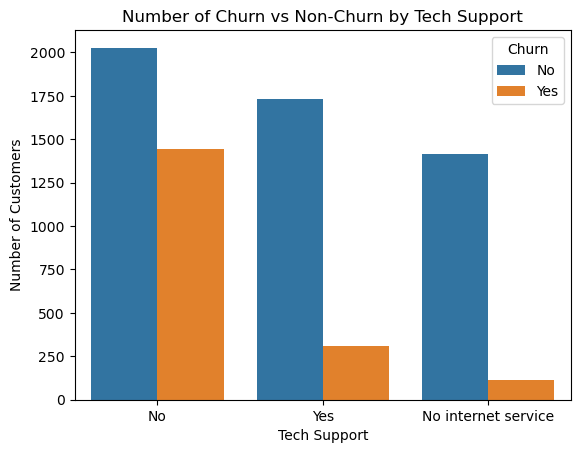

In [77]:
sns.countplot(
    data=df,
    x='TechSupport',
    hue='Churn'
)

plt.title('Number of Churn vs Non-Churn by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_37948\3639632516.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


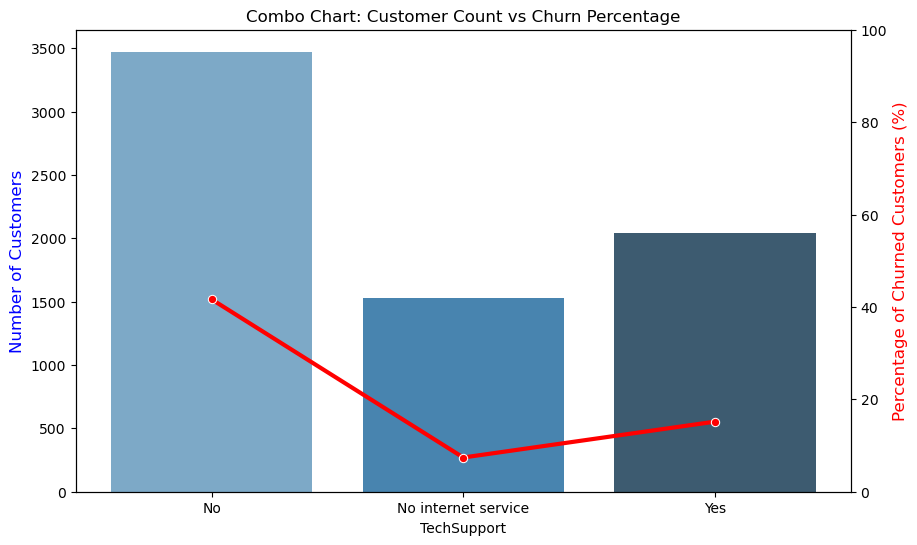

In [78]:
# 1. Setup your data
data = df

aggregated_data = data.groupby('TechSupport').agg({'Churn': lambda x: (x == 'Yes').mean() * 100, 'customerID': 'count'}).reset_index()

# kind = data['DeviceProtection'].unique()

# customer = data.groupby('DeviceProtection')['customerID'].count()

# churn = (
#     data.groupby('DeviceProtection')['Churn']
#     .apply(lambda x: (x == 'Yes').mean()) * 100
# )

# 2. Create the first plot (Bar Chart)
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=aggregated_data['TechSupport'],
    y=aggregated_data['customerID'],
    ax=ax1,
    palette="Blues_d"
)

ax1.set_ylabel('Number of Customers', color='blue', fontsize=12)

# 3. Create the second Y-axis
ax2 = ax1.twinx()

# Persentase 0–100%
ax2.set_ylim(0, 100)

# 4. Create the second plot (Line Chart)
sns.lineplot(
    x=aggregated_data['TechSupport'],
    y=aggregated_data['Churn'],
    marker='o',
    color='red',
    linewidth=3,
    ax=ax2
)

ax2.set_ylabel(
    'Percentage of Churned Customers (%)',
    color='red',
    fontsize=12
)

plt.title('Combo Chart: Customer Count vs Churn Percentage')
plt.xlabel('Device Protection')

plt.show()

It shows the higher churn is customers who do not use the Tech Support add-ons service, around 41.64%.

## 5. What is the distribution of total charges among churned and non-churned customers? Additionally, how does the average monthly charge relate to churn?

### a. Total Charges

In [79]:
df['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

<Axes: >

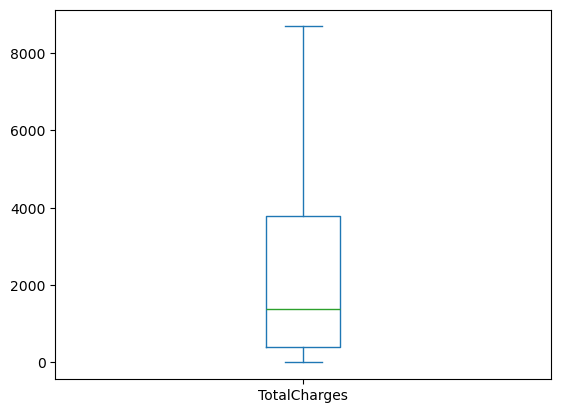

In [80]:
df['TotalCharges'].plot.box()

The boxplot does not show any outliers.

<Axes: xlabel='TotalCharges', ylabel='Count'>

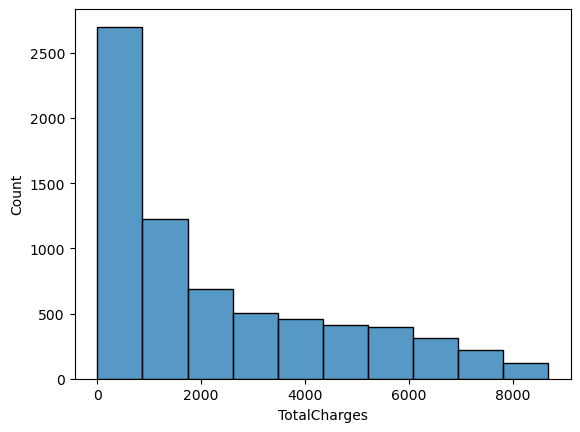

In [81]:
sns.histplot(x=df['TotalCharges'], bins=10)

In [82]:
TC_Churn_Yes = df[df['Churn'] == 'Yes']['TotalCharges']
TC_Churn_No = df[df['Churn'] == 'No']['TotalCharges']

In [83]:
TC_Churn_Yes.describe()

count    1869.000000
mean     1531.796094
std      1890.822994
min        18.850000
25%       134.500000
50%       703.550000
75%      2331.300000
max      8684.800000
Name: TotalCharges, dtype: float64

In [84]:
TC_Churn_No.describe()

count    5174.000000
mean     2549.911442
std      2329.954215
min         0.000000
25%       572.900000
50%      1679.525000
75%      4262.850000
max      8672.450000
Name: TotalCharges, dtype: float64

The average total charges for churned customers are $1,531.80, while for non-churned customers they are $2,549.91.

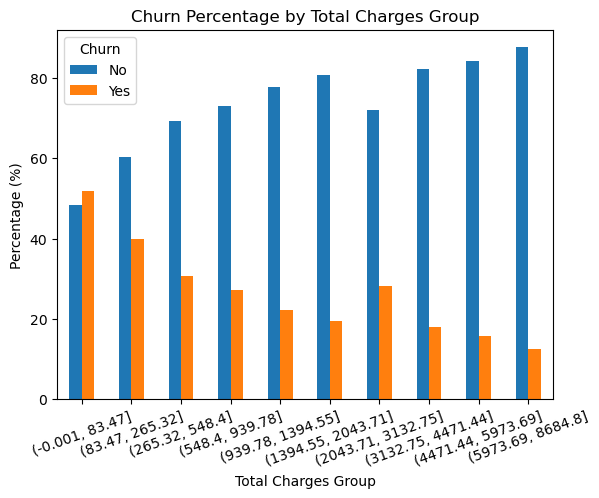

In [85]:
df['TC_group'] = pd.qcut(df['TotalCharges'], q=10)
tenure_churn_pct = pd.crosstab( df['TC_group'], df['Churn'], normalize='index' ) * 100
tenure_churn_pct.plot(kind='bar')

plt.title('Churn Percentage by Total Charges Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Total Charges Group')
plt.xticks(rotation=20)
plt.show()

In [86]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
result = df.groupby('TC_group')['Churn_binary'].mean() * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_37948\4131821319.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('TC_group')['Churn_binary'].mean() * 100


TC_group
(-0.001, 83.47]       51.773050
(83.47, 265.32]       39.772727
(265.32, 548.4]       30.681818
(548.4, 939.78]       27.130682
(939.78, 1394.55]     22.269504
(1394.55, 2043.71]    19.460227
(2043.71, 3132.75]    28.085106
(3132.75, 4471.44]    17.923186
(4471.44, 5973.69]    15.767045
(5973.69, 8684.8]     12.482270
Name: Churn_binary, dtype: float64

Percentage of customers who have Total Charges from $0 - $83.47 = 51.77%,
Percentage of customers who have Total Charges from $83.47 - $265.32 = 39.77%,
Percentage of customers who have Total Charges from $265.32 - $548.4 = 30.68%
Percentage of customers who have Total Charges from $548.4 - $939.78 = 27.13%
Percentage of customers who have Total Charges from $939.78 - $1394.55 = 22.26%
Percentage of customers who have Total Charges from $1394.55 - $2043.71 = 19.46%
Percentage of customers who have Total Charges from $2043.71 - $3132.75 = 28.08%
Percentage of customers who have Total Charges from $3132.75 - $4471.44 = 17.92%
Percentage of customers who have Total Charges from $4471.44 - $5973.69 = 15.76%
Percentage of customers who have Total Charges from $5973.69 - $8684.8 = 12.48%

Top 3 churn percentage of Total Charges is from $0 - $83.47 (51.77%), from $83.47 - $265.32 (39.77%), and from $265.32 - $548.4 (30.68%).

### b. Monthly Charges

In [87]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

<Axes: >

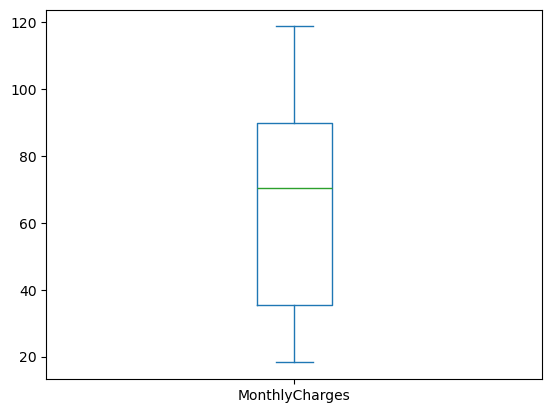

In [88]:
df['MonthlyCharges'].plot.box()

The boxplot does not show any outliers.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

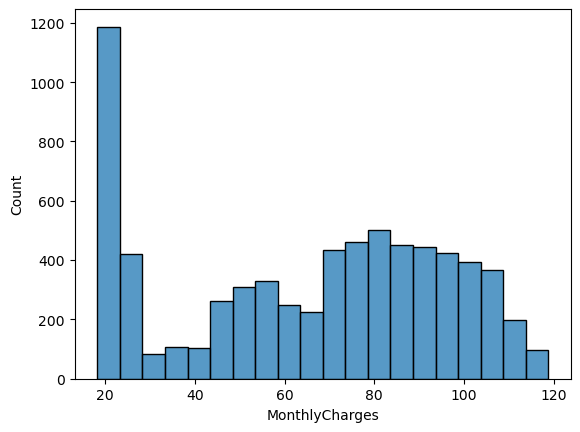

In [89]:
sns.histplot(x=df['MonthlyCharges'], bins=20)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

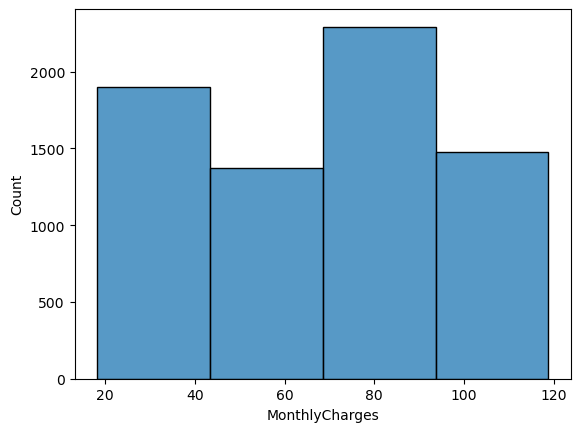

In [90]:
sns.histplot(x=df['MonthlyCharges'], bins=4)

In [91]:
MC_Churn_Yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
MC_Churn_Yes.describe()

count    1869.000000
mean       74.441332
std        24.666053
min        18.850000
25%        56.150000
50%        79.650000
75%        94.200000
max       118.350000
Name: MonthlyCharges, dtype: float64

In [92]:
MC_Churn_No = df[df['Churn'] == 'No']['MonthlyCharges']
MC_Churn_No.describe()

count    5174.000000
mean       61.265124
std        31.092648
min        18.250000
25%        25.100000
50%        64.425000
75%        88.400000
max       118.750000
Name: MonthlyCharges, dtype: float64

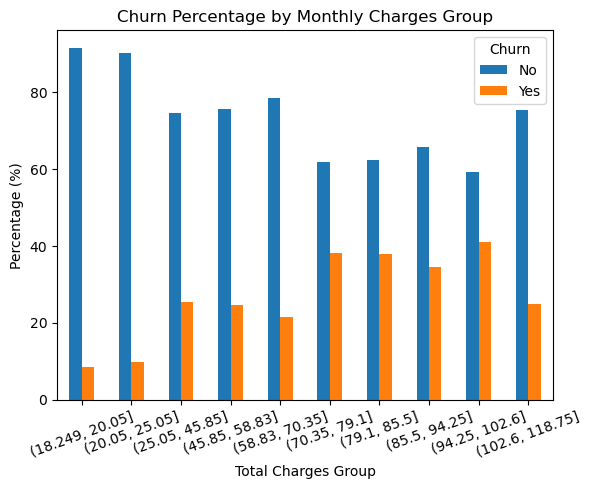

In [93]:
df['MC_group'] = pd.qcut(df['MonthlyCharges'], q=10)
tenure_churn_pct = pd.crosstab( df['MC_group'], df['Churn'], normalize='index' ) * 100
tenure_churn_pct.plot(kind='bar')

plt.title('Churn Percentage by Monthly Charges Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Total Charges Group')
plt.xticks(rotation=20)
plt.show()

In [94]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
result = df.groupby('MC_group')['Churn_binary'].mean() * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_37948\138406195.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('MC_group')['Churn_binary'].mean() * 100


MC_group
(18.249, 20.05]     8.507671
(20.05, 25.05]      9.815078
(25.05, 45.85]     25.467626
(45.85, 58.83]     24.501425
(58.83, 70.35]     21.518987
(70.35, 79.1]      38.142857
(79.1, 85.5]       37.872340
(85.5, 94.25]      34.330484
(94.25, 102.6]     40.909091
(102.6, 118.75]    24.715909
Name: Churn_binary, dtype: float64

Percentage of customers who have Monthly Charges from $18.249 - $20.05 = 8.5%,
Percentage of customers who have Monthly Charges from $20.05 - $20.05 = 9.81%,
Percentage of customers who have Monthly Charges from $25.05 - $45.85 = 25.46%,
Percentage of customers who have Monthly Charges from $45.85 - $58.83 = 24.50%,
Percentage of customers who have Monthly Charges from $58.83 - $70.35 = 21.51%,
Percentage of customers who have Monthly Charges from $70.35 - $79.1 = 38.14%,
Percentage of customers who have Monthly Charges from $79.1 - $85.5 = 37.87%,
Percentage of customers who have Monthly Charges from $85.5 - $94.25 = 34.33%,
Percentage of customers who have Monthly Charges from $94.25 - $102.6 = 40.9%,
Percentage of customers who have Monthly Charges from $102.6 - $118.75 = 24.71%.

Top 3 churn percentage of Monthly Charges is from $94.25 - $102.6 (40.9%), from $70.35 - $79.1 (38.14%), and from $79.1 - $85.5 (37.87%).

## 6. How is customer data distributed based on tenure? Is there a difference in churn rate compared to non-churn customers, and what the correlation between tenure and churn?

<Axes: >

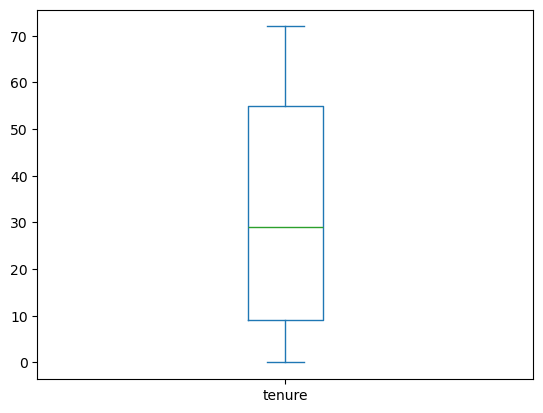

In [95]:
df['tenure'].plot.box()

The boxplot does not show any outliers.

<Axes: xlabel='tenure', ylabel='Count'>

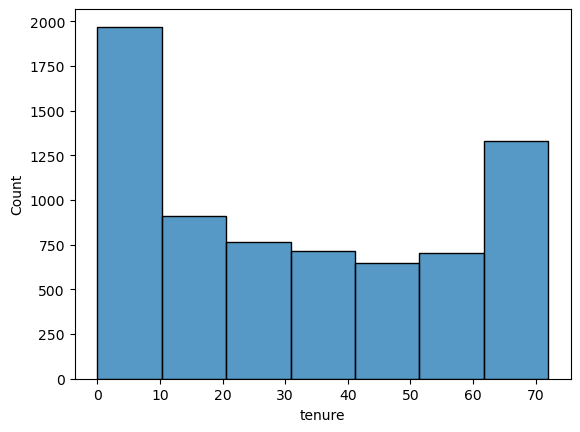

In [96]:
sns.histplot(x=df['tenure'], bins=7)

In [97]:
Tenure_max10 = df[df['tenure'] <= 10]
Tenure_min60 = df[df['tenure'] >= 60]

In [98]:
print(f'''
      Number of customers with tenure less than or equal to 10 months = {len(Tenure_max10)} ({len(Tenure_max10)/len(df)*100:.2f}%), 
      Number of customers with tenure greater than or equal to 60 months = {len(Tenure_min60)} ({len(Tenure_min60)/len(df)*100:.2f}%), 
      Total number of customers = {len(df)}
      ''')


      Number of customers with tenure less than or equal to 10 months = 1970 (27.97%), 
      Number of customers with tenure greater than or equal to 60 months = 1483 (21.06%), 
      Total number of customers = 7043
      


The number of service users is higher tenure is below 10 months (27.98%, totaling 1970 customers) and above 60 months (21%, totaling 1483 customers), from 7043 customers.


In [99]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

It's show mean of tenure that customers use the service is 32 months (2 Years 8 Months)

In [100]:
Tenure_Churn_Yes = df[df['Churn'] == 'Yes']['tenure']
Tenure_Churn_Yes.describe()

count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64

Mean of churn tenure is 18 months (1 years 6 months/1.5 years)

<Axes: xlabel='tenure', ylabel='Count'>

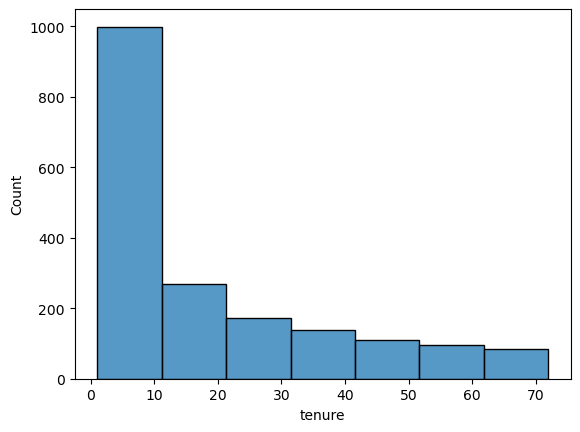

In [101]:
sns.histplot(x=Tenure_Churn_Yes, bins=7)

In [102]:
Tenure_Churn_No = df[df['Churn'] == 'No']['tenure']
Tenure_Churn_No.describe()

count    5174.000000
mean       37.569965
std        24.113777
min         0.000000
25%        15.000000
50%        38.000000
75%        61.000000
max        72.000000
Name: tenure, dtype: float64

<Axes: xlabel='tenure', ylabel='Count'>

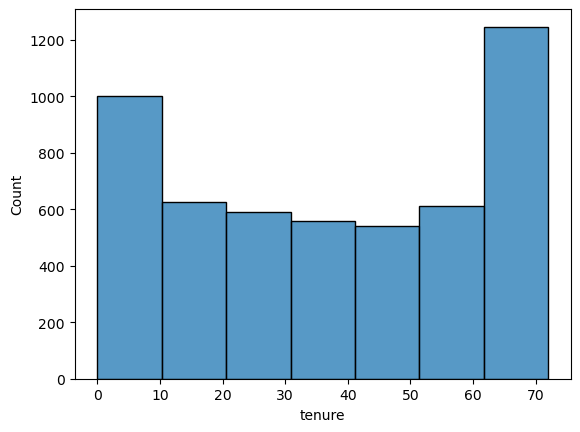

In [103]:
sns.histplot(x=Tenure_Churn_No, bins=7)

In [104]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


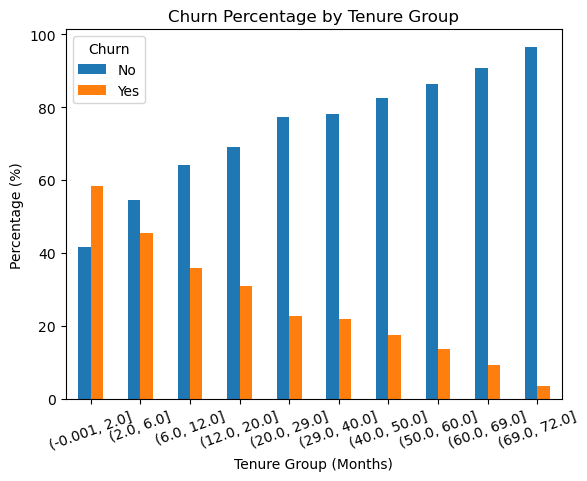

In [105]:
df['tenure_group'] = pd.qcut(df['tenure'], q=10)
tenure_churn_pct = pd.crosstab( df['tenure_group'], df['Churn'], normalize='index' ) * 100
tenure_churn_pct.plot(kind='bar')

plt.title('Churn Percentage by Tenure Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Tenure Group (Months)')
plt.xticks(rotation=20)
plt.show()

In [106]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
result = df.groupby('tenure_group')['Churn_binary'].mean() * 100
result

C:\Users\User\AppData\Local\Temp\ipykernel_37948\170926080.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('tenure_group')['Churn_binary'].mean() * 100


tenure_group
(-0.001, 2.0]    58.352668
(2.0, 6.0]       45.395800
(6.0, 12.0]      35.886525
(12.0, 20.0]     30.924855
(20.0, 29.0]     22.865412
(29.0, 40.0]     21.896792
(40.0, 50.0]     17.638037
(50.0, 60.0]     13.610315
(60.0, 69.0]      9.259259
(69.0, 72.0]      3.533026
Name: Churn_binary, dtype: float64

Percentage of customers who have tenure from 0 - 2 = 58.35%,

Percentage of customers who have tenure from 2 - 6 = 45.39%,

Percentage of customers who have tenure from 6 - 12 = 35.88%,

Percentage of customers who have tenure from 12 - 20 = 30.92%,

Percentage of customers who have tenure from 20 - 29 = 22.86%,

Percentage of customers who have tenure from 29 - 40 = 21.89%,

Percentage of customers who have tenure from 40 - 50 = 17.63%,

Percentage of customers who have tenure from 50 - 60 = 13.61%,

Percentage of customers who have tenure from 60 - 69 = 9.25%,

Percentage of customers who have tenure from 69 - 72 = 3.53%,

Top 3 Percentage of Tenure is from 0 - 2 months (58.35%), from 2 - 6 months (45.39%), and from 6 - 12 (35.88%).

In [107]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Is_Security_Add_Ons,TC_group,Churn_binary,MC_group,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,Yes,"(-0.001, 83.47]",0,"(25.05, 45.85]","(-0.001, 2.0]"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,Yes,"(1394.55, 2043.71]",0,"(45.85, 58.83]","(29.0, 40.0]"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,Yes,"(83.47, 265.32]",1,"(45.85, 58.83]","(-0.001, 2.0]"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,Yes,"(1394.55, 2043.71]",0,"(25.05, 45.85]","(40.0, 50.0]"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,No,"(83.47, 265.32]",1,"(70.35, 79.1]","(-0.001, 2.0]"


In [ ]:
# corr_r, pval_p = stats.pearsonr(df['Churn_binary'], df['tenure'])
# corr_rho, pval_s = stats.spearmanr(df['Churn_binary'], df['tenure'])
# corr_tau, pval_k = stats.kendalltau(df['Churn_binary'], df['tenure'])
corr_pb, pval_pb = stats.pointbiserialr(df['Churn_binary'], df['tenure']) # use point-biserial correlation for binary and continuous variables

# print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")
# print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")
# print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")
print(f"point-biserial correlation: {corr_pb:.2f}, p-value: {pval_pb}")

point-biserial correlation: -0.35, p-value: 7.9990579605966e-205


In [112]:
# Interpretation of results
alpha = 0.05
if pval_pb < alpha:
    print(f"\n✅ Reject H0 — There is a significant relationship between tenure and churn.")
else:
    print(f"\n❌ Fail to Reject H0 — There is no significant relationship between tenure and churn.")

# Direction of relationship
if corr_pb < 0:
    print(f"📉 Direction: Negative → The longer the tenure, the lower the chance of churn.")
else:
    print(f"📈 Direction: Positive → The longer the tenure, the higher the chance of churn.")


✅ Reject H0 — There is a significant relationship between tenure and churn.
📉 Direction: Negative → The longer the tenure, the lower the chance of churn.


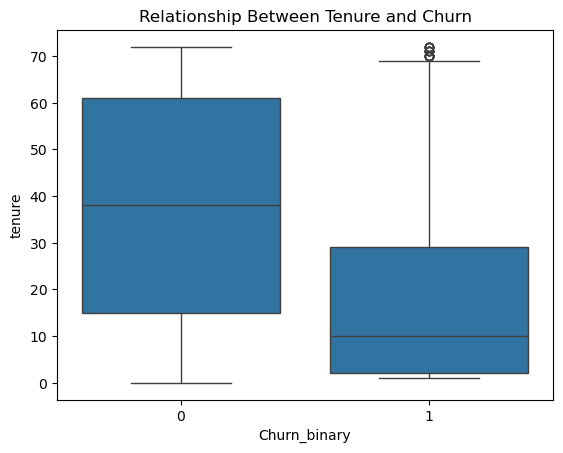

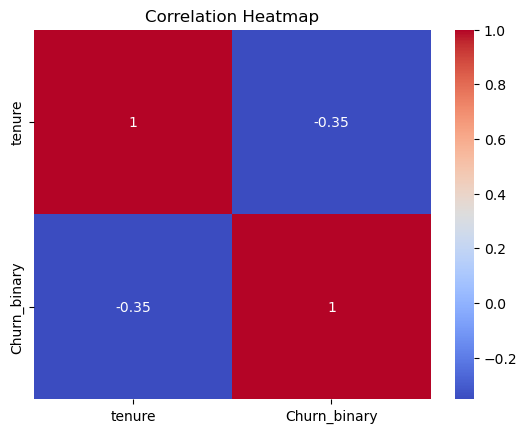

In [115]:
# Boxplot
sns.boxplot(x='Churn_binary', y='tenure', data=df)
plt.title('Relationship Between Tenure and Churn')
plt.show()

# Heatmap korelasi
sns.heatmap(df[['tenure', 'Churn_binary']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Red → positive correlation

Blue → negative correlation

The darker the color → the stronger the correlation

From a business perspective, if tenure has a negative correlation with churn:

* New customers are more likely to churn
* The company needs to focus on retention during the early stages of subscription
* Early onboarding and engagement become crucial

## 7. What is the top 10 that have high percentage in churn?

Top 10 companies with the highest churn:

1. Percentage of customers who have tenure from 0 - 2 months = 58.35%

2. Percentage of customers who have Total Charges from $0 - $83.47 = 51.77%

3. Percentage of customers who have tenure from 2 - 6 months (45.39%)

4. Percentage of customers with electronic check payment method who churned = 45.29%

5. Percentage of customers with a month-to-month contract who churned = 42.71%

6. Percentage of customers who do not use online security and churn = 41.77%

7. Percentage of senior citizen customers who churned = 41.68%

8. Percentage of customers who do not use tech support and churn = 41.64%

9. Percentage of customers who have Monthly Charges from $94.25 - $102.6 = 40.9%

10. Percentage of customers who do not use online backup and churn = 39.93%